# FBI Crime Investigation - Time Series Forecasting

| Detail | Value |
|--------|-------|
| **Project Name** | FBI Crime Investigation - Time Series Forecasting |
| **Project Type** | Regression / Time Series Forecasting |
| **Contribution** | Individual |
| **Team Member** | Data Scientist |

## Project Summary

This project uses historical crime data from Vancouver (1999-2011) to build a model that predicts monthly crime counts across 9 crime categories. The dataset has ~474K records with features like crime type, location (lat/lon, neighbourhood), and timestamp.

The core problem is a time series regression: given past incident counts, predict how many crimes of each type will happen each month from Jan 2012 to Jun 2013 (162 predictions total).

Approach: aggregate raw incident data to monthly counts per crime type, engineer lag and rolling features to capture temporal patterns, then compare XGBoost, Random Forest, and SARIMA. The best model is retrained on all available data before generating final predictions.

The 9 crime types are: Theft from Vehicle, Mischief, Break and Enter Commercial, Theft of Vehicle, Other Theft, Break and Enter Residential/Other, Offence Against a Person, Vehicle Collision or Pedestrian Struck, Theft of Bicycle.

## GitHub Link

[GitHub Repository Link - To Be Added](#)

## Problem Statement

We have ~474K crime records from Vancouver covering 1999 to 2011. Each record has 13 features: TYPE, HUNDRED_BLOCK, NEIGHBOURHOOD, X, Y, Latitude, Longitude, HOUR, MINUTE, YEAR, MONTH, DAY, and Date.

The task is to predict the monthly Incident_Count for each of the 9 crime types from January 2012 through June 2013 — 18 months x 9 types = 162 predictions.

Key challenges:
- Missing values in NEIGHBOURHOOD (~51K) and HOUR/MINUTE (~49K, all tied to Offence Against a Person)
- Need to aggregate raw incident-level data to monthly counts
- Lag features must be constructed carefully to avoid data leakage
- Test-time predictions need to be generated iteratively since each month's lag features depend on the previous month's prediction

## General Guidelines

1. Well-structured, formatted, and commented code is required for every question.
2. Exception handling and production-quality code will be evaluated.
3. All charts must have proper titles, labeled axes, and legends where applicable.
4. Each chart must be accompanied by: **Why this chart?**, **Insight**, and **Business Impact**.
5. Every hypothesis must include a statistical test, test statistic, p-value, and conclusion.
6. The final model must be saved and the submission file must be generated.

---
# Section 1: Know Your Data

### 1.1 Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, f_oneway
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import xgboost as xgb
import joblib
import os

All libraries imported successfully.


### 1.1b Environment Setup

In [ ]:
import os

IN_COLAB = 'COLAB_GPU' in os.environ or 'google.colab' in str(os.environ.get('_', ''))

if IN_COLAB:
    BASE = '/content'
else:
    BASE = r"D:/FBI's-Crime-Investigation"

print(f"Environment : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"BASE path   : {BASE}")

### 1.2 Load Data

In [ ]:
train = pd.read_excel(f"{BASE}/Train.xlsx")
test  = pd.read_csv(f"{BASE}/Test.csv")
print(f"Train: {train.shape}  |  Test: {test.shape}")

Train shape: (474565, 13)
Test shape: (162, 4)


### 1.3 First View of Data

In [ ]:
train.head()

TRAINING DATA - First 5 Rows


,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
0,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,15.0,1999,5,12,1999-05-12
1,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,15.0,20.0,1999,5,7,1999-05-07
2,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,40.0,1999,4,23,1999-04-23
3,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,11.0,15.0,1999,4,20,1999-04-20
4,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,17.0,45.0,1999,4,12,1999-04-12


In [ ]:
train.tail()

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
474560,Theft from Vehicle,E 28TH AVE / FRASER ST,Riley Park,493434.25,5454756.06,49.245542,-123.090211,19.0,0.0,2011,10,29,2011-10-29
474561,Theft from Vehicle,E 28TH AVE / FRASER ST,Riley Park,493434.25,5454756.06,49.245542,-123.090211,23.0,0.0,2011,3,9,2011-03-09
474562,Other Theft,23XX CAMBIE ST,Mount Pleasant,491656.42,5456901.55,49.264820,-123.114682,17.0,52.0,2011,2,10,2011-02-10
474563,Other Theft,7XX BUTE ST,West End,490797.66,5459282.31,49.286223,-123.126541,18.0,0.0,2011,12,20,2011-12-20
474564,Mischief,57XX MAIN ST,Sunset,492605.32,5453354.38,49.232924,-123.101574,18.0,30.0,2011,2,3,2011-02-03


In [ ]:
test.head()

TEST DATA - First 5 Rows


,YEAR,MONTH,TYPE,Incident_Counts
0,2013,6,Vehicle Collision or Pedestrian Struck (with I...,NaN
1,2013,6,Theft of Vehicle,NaN
2,2013,6,Theft of Bicycle,NaN
3,2013,6,Theft from Vehicle,NaN
4,2013,6,Other Theft,NaN


### 1.4 Rows and Columns

In [ ]:
print(f"Train : {train.shape[0]} rows x {train.shape[1]} cols")
print(f"Test  : {test.shape[0]} rows x {test.shape[1]} cols")
print(f"\nTrain cols: {list(train.columns)}")
print(f"Test  cols: {list(test.columns)}")

Training data: 474565 rows, 13 columns
Test data: 162 rows, 4 columns

Training columns: ['TYPE', 'HUNDRED_BLOCK', 'NEIGHBOURHOOD', 'X', 'Y', 'Latitude', 'Longitude', 'HOUR', 'MINUTE', 'YEAR', 'MONTH', 'DAY', 'Date']

Test columns: ['YEAR', 'MONTH', 'TYPE', 'Incident_Counts']


### 1.5 Data Info

In [ ]:
train.info()
print()
test.info()

TRAINING DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474565 entries, 0 to 474564
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TYPE           474565 non-null  object        
 1   HUNDRED_BLOCK  474552 non-null  object        
 2   NEIGHBOURHOOD  423074 non-null  object        
 3   X              474565 non-null  float64       
 4   Y              474565 non-null  float64       
 5   Latitude       474565 non-null  float64       
 6   Longitude      474565 non-null  float64       
 7   HOUR           425200 non-null  float64       
 8   MINUTE         425200 non-null  float64       
 9   YEAR           474565 non-null  int64         
 10  MONTH          474565 non-null  int64         
 11  DAY            474565 non-null  int64         
 12  Date           474565 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), int64(3), object(3)
memory usage: 47.1+ MB


TEST D

### 1.6 Duplicate Check

In [ ]:
print(f"Train duplicates : {train.duplicated().sum()}")
print(f"Test  duplicates : {test.duplicated().sum()}")

Duplicate rows in training data: 44618
Duplicate rows in test data: 0


### 1.7 Missing Values

In [ ]:
train_missing = train.isnull().sum()
train_missing_pct = (train.isnull().sum() / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Missing_Count': train_missing, 'Missing_Pct': train_missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)
print(f"\nTotal missing: {train.isnull().sum().sum()}")

MISSING VALUES IN TRAINING DATA
               Missing_Count  Missing_Percentage
NEIGHBOURHOOD          51491               10.85
HOUR                   49365               10.40
MINUTE                 49365               10.40
HUNDRED_BLOCK             13                0.00

Total missing values: 150234


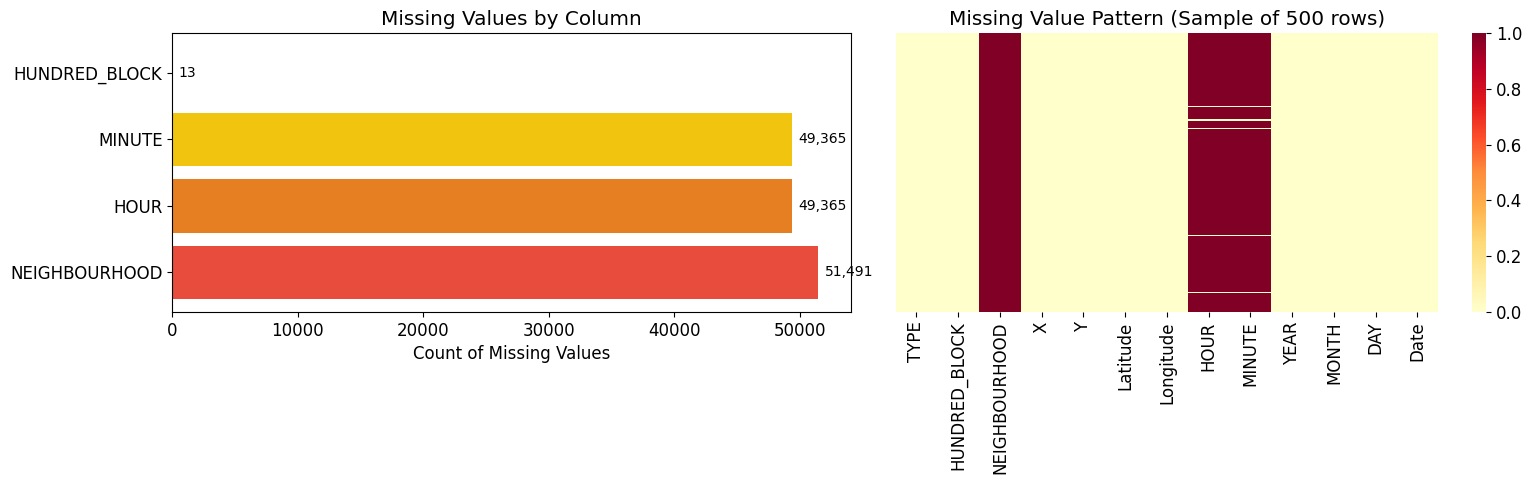

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

missing_cols   = missing_df.index.tolist()
missing_counts = missing_df['Missing_Count'].values

axes[0].barh(missing_cols, missing_counts, color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'])
axes[0].set_xlabel('Missing Count')
axes[0].set_title('Missing Values by Column')
for i, v in enumerate(missing_counts):
    axes[0].text(v + 500, i, f'{v:,}', va='center', fontsize=10)

sample_idx = train[train.isnull().any(axis=1)].sample(
    min(500, train.isnull().any(axis=1).sum()), random_state=42).index
sns.heatmap(train.loc[sample_idx].isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Missing Pattern (500-row sample)')

plt.tight_layout()
plt.show()

In [ ]:
print("HOUR missing by crime type:")
print(train[train['HOUR'].isnull()]['TYPE'].value_counts())
print("\nNEIGHBOURHOOD missing by crime type:")
print(train[train['NEIGHBOURHOOD'].isnull()]['TYPE'].value_counts().head(10))

Missing HOUR values by crime type:
TYPE
Offence Against a Person    49365
Name: count, dtype: int64

Missing NEIGHBOURHOOD values by crime type:
TYPE
Offence Against a Person                                49365
Theft from Vehicle                                       1715
Mischief                                                  227
Theft of Bicycle                                          103
Theft of Vehicle                                           61
Vehicle Collision or Pedestrian Struck (with Injury)       10
Other Theft                                                 4
Break and Enter Residential/Other                           3
Break and Enter Commercial                                  3
Name: count, dtype: int64


NEIGHBOURHOOD has the most missing values (~51K, ~10.7%), spread across multiple crime types. These are likely incidents outside mapped neighbourhood boundaries or with no address precision. HOUR and MINUTE are missing ~49K times, almost entirely for Offence Against a Person — time of occurrence is often not recorded for these crimes. HUNDRED_BLOCK has only 13 missing entries, essentially negligible.

Since the model aggregates to monthly counts, losing neighbourhood or time-of-day info doesn't affect the target variable directly.

---
# Section 2: Understanding Your Variables

### 2.1 Column Names and Data Types

In [ ]:
print("Column overview:")
for col in train.columns:
    print(f"  {col:20s}  {str(train[col].dtype):12s}  non-null: {train[col].notna().sum():,}")

Training Data Columns and Types:
TYPE                 -> object          (Non-null: 474,565)
HUNDRED_BLOCK        -> object          (Non-null: 474,552)
NEIGHBOURHOOD        -> object          (Non-null: 423,074)
X                    -> float64         (Non-null: 474,565)
Y                    -> float64         (Non-null: 474,565)
Latitude             -> float64         (Non-null: 474,565)
Longitude            -> float64         (Non-null: 474,565)
HOUR                 -> float64         (Non-null: 425,200)
MINUTE               -> float64         (Non-null: 425,200)
YEAR                 -> int64           (Non-null: 474,565)
MONTH                -> int64           (Non-null: 474,565)
DAY                  -> int64           (Non-null: 474,565)
Date                 -> datetime64[ns]  (Non-null: 474,565)


### 2.2 Descriptive Statistics

In [ ]:
train.describe()

DESCRIPTIVE STATISTICS - NUMERICAL


,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
count,474565.000000,4.745650e+05,474565.000000,474565.000000,425200.000000,425200.000000,474565.000000,474565.000000,474565.000000,474565
mean,441028.018220,4.889023e+06,44.138029,-110.301025,13.721263,16.736047,2004.363632,6.555700,15.439253,2004-11-11 23:51:07.470209792
min,0.000000,0.000000e+00,0.000000,-124.549757,0.000000,0.000000,1999.000000,1.000000,1.000000,1999-01-01 00:00:00
25%,489916.530000,5.453572e+06,49.234871,-123.127383,9.000000,0.000000,2001.000000,4.000000,8.000000,2001-06-06 00:00:00
50%,491477.850000,5.456820e+06,49.264051,-123.107058,15.000000,10.000000,2004.000000,7.000000,15.000000,2004-05-18 00:00:00
75%,493610.190000,5.458622e+06,49.280300,-123.065646,19.000000,30.000000,2008.000000,9.000000,23.000000,2008-03-27 00:00:00
max,511303.000000,5.512579e+06,49.755314,0.000000,23.000000,59.000000,2011.000000,12.000000,31.000000,2011-12-31 00:00:00
std,150295.319332,1.665850e+06,15.039271,37.583147,6.785751,18.354675,3.850689,3.408676,8.759352,NaN


In [ ]:
train.describe(include='object')

DESCRIPTIVE STATISTICS - CATEGORICAL


,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD
count,474565,474552,423074
unique,9,20566,24
top,Theft from Vehicle,OFFSET TO PROTECT PRIVACY,Central Business District
freq,153932,49365,96171


### 2.3 Variable Descriptions

| Variable | Description | Type |
|----------|-------------|------|
| TYPE | Crime category (9 unique types) | Categorical |
| HUNDRED_BLOCK | Approximate street address block | Categorical |
| NEIGHBOURHOOD | Vancouver neighbourhood name | Categorical |
| X | UTM Easting coordinate | Numerical |
| Y | UTM Northing coordinate | Numerical |
| Latitude | Geographic latitude | Numerical |
| Longitude | Geographic longitude | Numerical |
| HOUR | Hour of day the crime occurred (0-23) | Numerical |
| MINUTE | Minute the crime occurred (0-59) | Numerical |
| YEAR | Year of the crime (1999-2011) | Numerical |
| MONTH | Month of the crime (1-12) | Numerical |
| DAY | Day of month (1-31) | Numerical |
| Date | Full date of the crime | Datetime |

### 2.4 Unique Values

In [ ]:
for col in train.columns:
    n = train[col].nunique()
    print(f"{col:20s} -> {n:,} unique")
    if n <= 15:
        print(f"  {sorted(train[col].dropna().unique())}")

Unique values per column:
TYPE                 -> 9 unique values
                        Values: ['Break and Enter Commercial', 'Break and Enter Residential/Other', 'Mischief', 'Offence Against a Person', 'Other Theft', 'Theft from Vehicle', 'Theft of Bicycle', 'Theft of Vehicle', 'Vehicle Collision or Pedestrian Struck (with Injury)']
HUNDRED_BLOCK        -> 20,566 unique values
NEIGHBOURHOOD        -> 24 unique values
X                    -> 84,225 unique values
Y                    -> 82,768 unique values
Latitude             -> 89,488 unique values
Longitude            -> 87,190 unique values
HOUR                 -> 24 unique values
MINUTE               -> 60 unique values
YEAR                 -> 13 unique values
                        Values: [np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011)]
MONTH                -> 12 uniq

---
# Section 3: Data Wrangling

### 3.1 Handle Missing Values

In [ ]:
train['HUNDRED_BLOCK'] = train['HUNDRED_BLOCK'].fillna('Unknown')
train['NEIGHBOURHOOD'] = train['NEIGHBOURHOOD'].fillna('Unknown')

# HOUR/MINUTE nulls all come from Offence Against a Person; -1 as sentinel
# since the model aggregates to monthly counts and doesn't use exact time
train['HOUR']   = train['HOUR'].fillna(-1).astype(int)
train['MINUTE'] = train['MINUTE'].fillna(-1).astype(int)

print(f"Remaining nulls: {train.isnull().sum().sum()}")

HUNDRED_BLOCK missing after fill: 0
NEIGHBOURHOOD missing after fill: 0
HOUR missing after fill: 0
MINUTE missing after fill: 0

Total missing values remaining: 0


Missing value strategy:
- HUNDRED_BLOCK (13 missing): filled with 'Unknown', too few to worry about
- NEIGHBOURHOOD (~51K): filled with 'Unknown' — the EDA uses this column but the final model doesn't, so these records are still valid for monthly count aggregation
- HOUR/MINUTE (~49K): filled with -1 as a sentinel, since the target is monthly count not hour-level, and these are all from one crime type (Offence Against a Person)

No rows are dropped — all 474,565 records are kept.

---
# Section 4: Data Visualization (15 Charts)

### Chart 1: Crime Type Distribution

Theft from Vehicle dominates the dataset with ~153K incidents (about 32% of total), followed by Mischief (~63K) and Other Theft (~55K). At the other end, Theft of Bicycle and Vehicle Collision are the least frequent. The distribution is right-skewed — a handful of crime types account for the majority of records. This is expected for crime data in urban settings where property crimes are more common than violent offences.

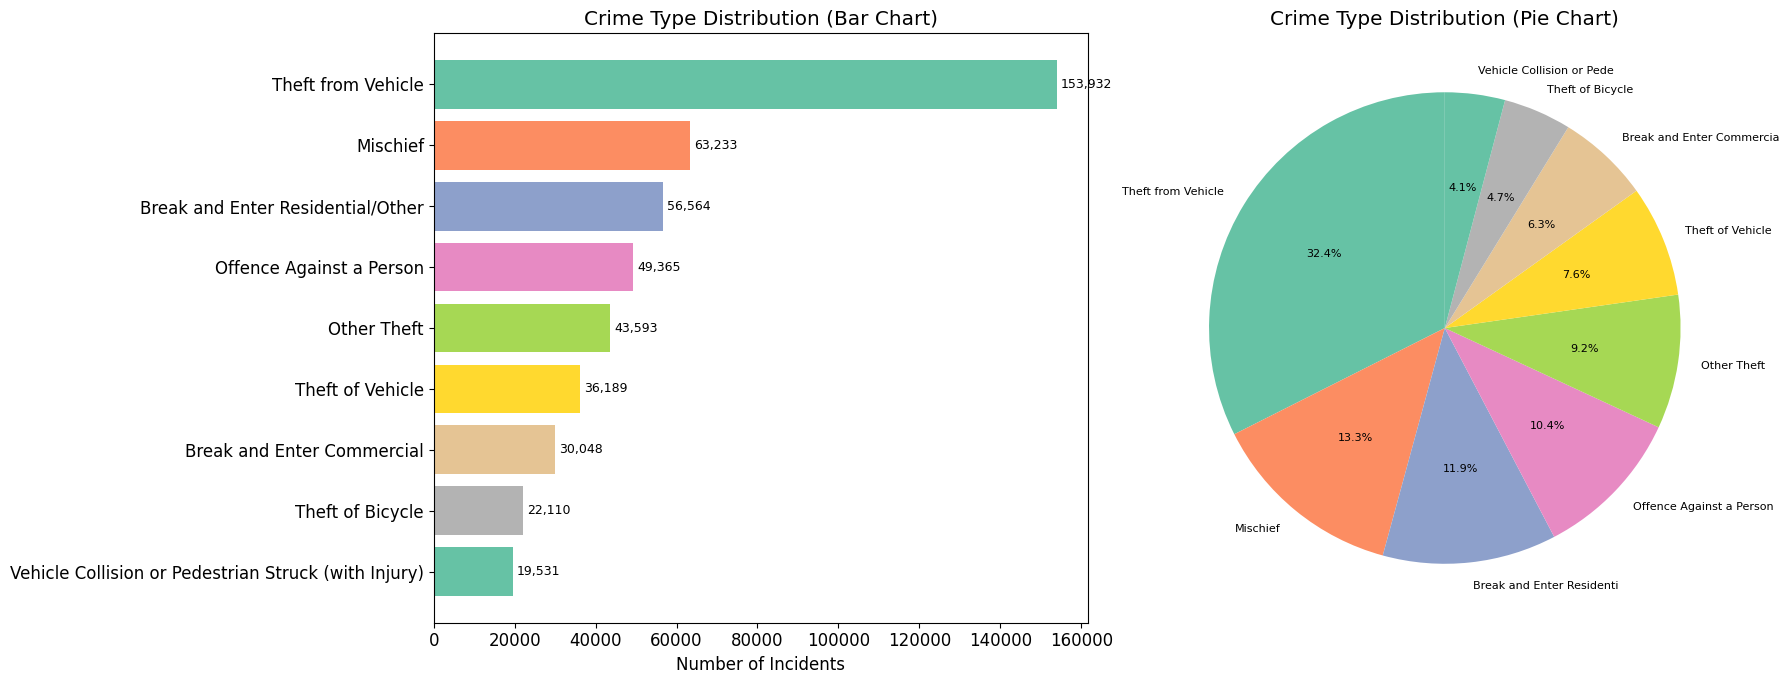

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

type_counts = train['TYPE'].value_counts()
colors = sns.color_palette('Set2', n_colors=len(type_counts))

bars = axes[0].barh(type_counts.index[::-1], type_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel('Number of Incidents')
axes[0].set_title('Crime Type Distribution')
for bar_item in bars:
    w = bar_item.get_width()
    axes[0].text(w + 1000, bar_item.get_y() + bar_item.get_height()/2,
                 f'{int(w):,}', va='center', fontsize=9)

axes[1].pie(type_counts.values, labels=[t[:25] for t in type_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 8})
axes[1].set_title('Crime Type Share')

plt.tight_layout()
plt.show()

### Chart 2: Yearly Total Crime Trend

Total crime declined from 1999 through the early 2000s, then stabilized around 2005 onwards with minor year-to-year variation. The data doesn't show a sharp spike or crash in any single year. For forecasting purposes, this stable mid-period trend means the model doesn't need to extrapolate an accelerating or decelerating trend — a roughly flat baseline with seasonal variation is a reasonable prior.

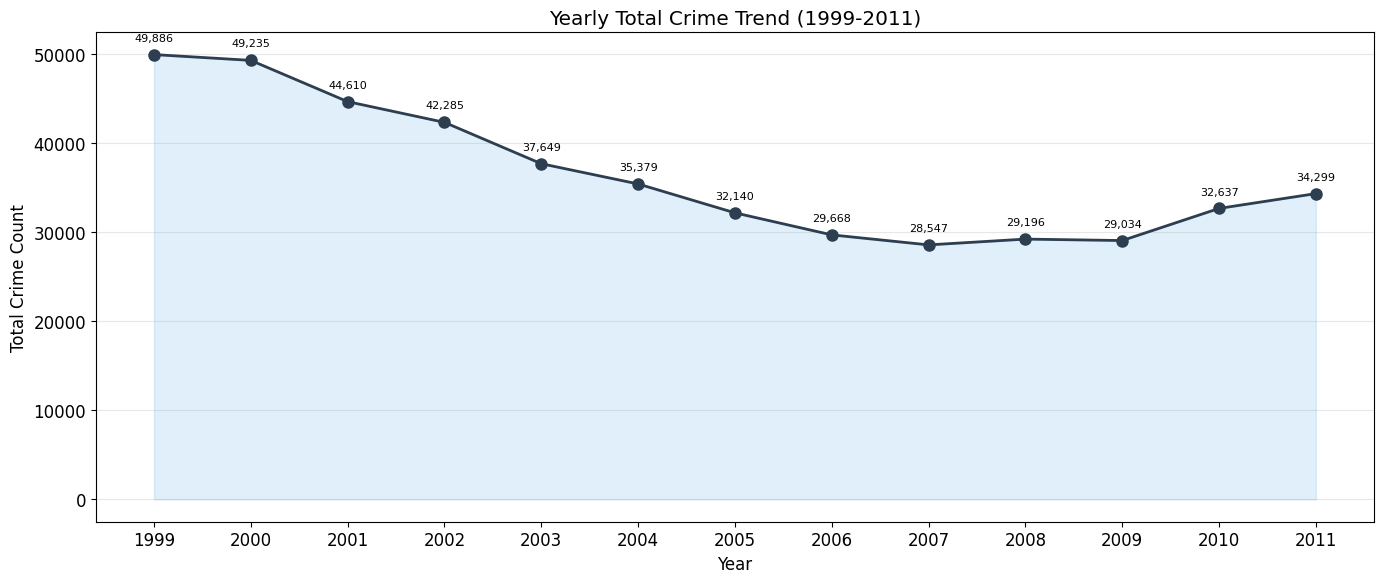

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

yearly_counts = train.groupby('YEAR').size().reset_index(name='Count')
ax.plot(yearly_counts['YEAR'], yearly_counts['Count'], marker='o', linewidth=2,
        color='#2c3e50', markersize=8)
ax.fill_between(yearly_counts['YEAR'], yearly_counts['Count'], alpha=0.15, color='#3498db')
ax.set_xlabel('Year'); ax.set_ylabel('Total Crimes')
ax.set_title('Yearly Crime Trend (1999-2011)')
ax.set_xticks(yearly_counts['YEAR'])
ax.grid(axis='y', alpha=0.3)

for _, row in yearly_counts.iterrows():
    ax.annotate(f"{int(row['Count']):,}", (row['YEAR'], row['Count']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### Chart 3: Yearly Trends by Crime Type

Theft from Vehicle and Theft of Vehicle both show a meaningful decline from 1999-2005, then level off — likely reflecting improvements in vehicle security technology. Theft of Bicycle moves in the opposite direction, growing steadily through the 2000s as cycling became more popular. Other categories like Mischief and Break and Enter stay relatively flat. These diverging trajectories matter for forecasting: each crime type needs its own trend component.

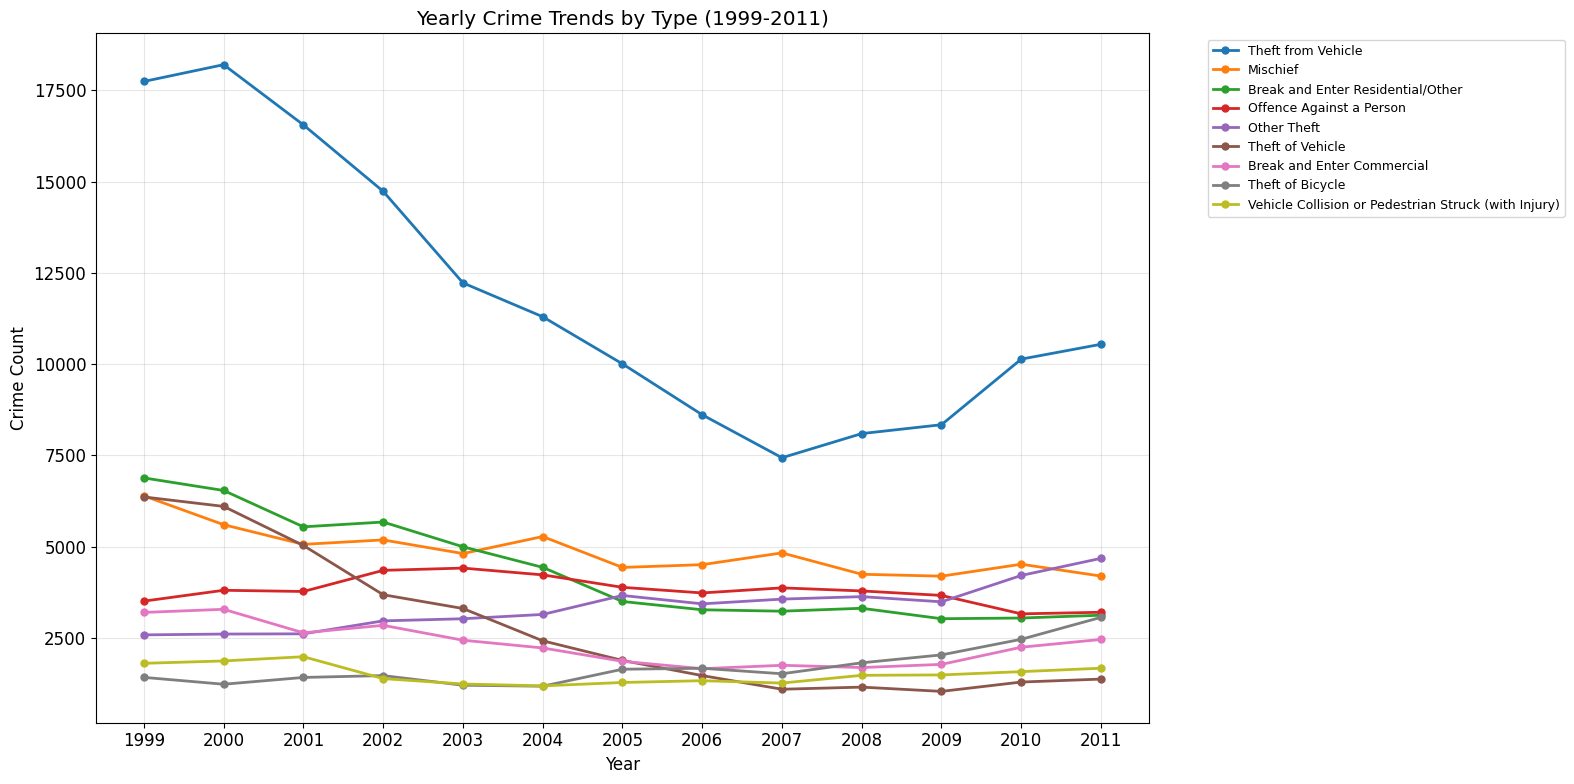

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

yearly_type = train.groupby(['YEAR', 'TYPE']).size().reset_index(name='Count')
for crime_type in type_counts.index:
    subset = yearly_type[yearly_type['TYPE'] == crime_type]
    ax.plot(subset['YEAR'], subset['Count'], marker='o', linewidth=2,
            label=crime_type, markersize=5)

ax.set_xlabel('Year'); ax.set_ylabel('Count')
ax.set_title('Yearly Trends by Crime Type')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3); ax.set_xticks(range(1999, 2012))

plt.tight_layout()
plt.show()

### Chart 4: Monthly Seasonality

June, July, and August consistently have more crime than the rest of the year. December and January tend to be the quietest months. The gap between summer and winter is roughly 15-20%. This seasonal pattern is strong enough to be one of the model's most useful predictors — confirmed later by the feature importance results.

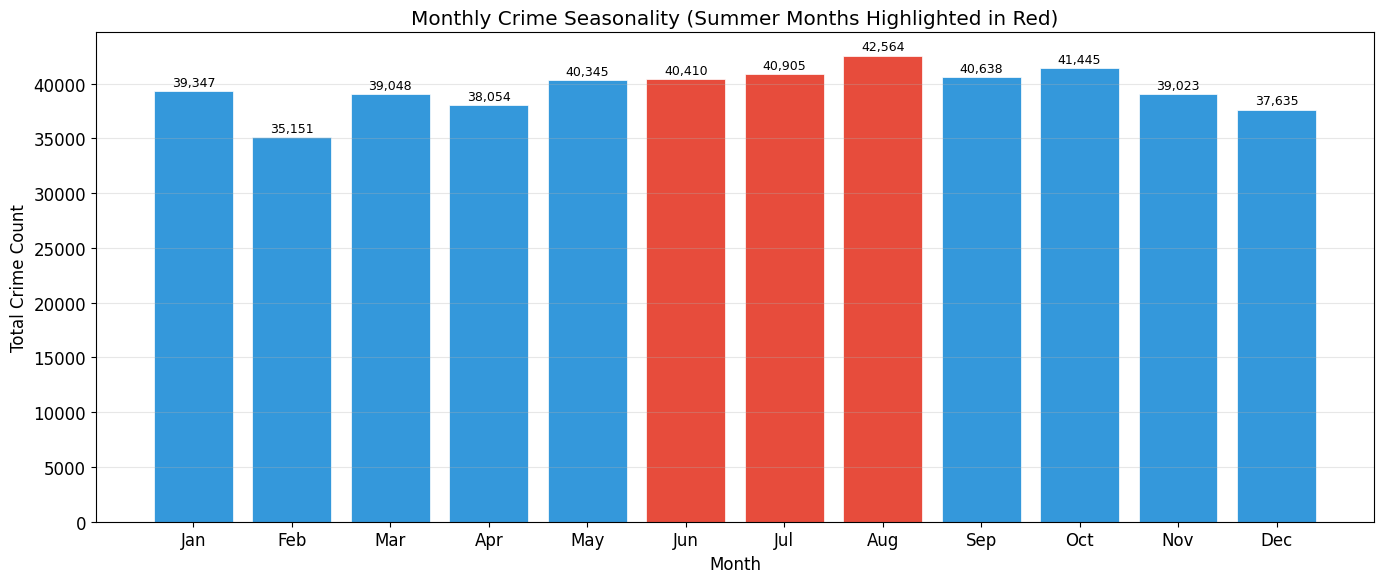

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

monthly_counts = train.groupby('MONTH').size().reset_index(name='Count')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bar_colors = ['#e74c3c' if m in [6,7,8] else '#3498db' for m in range(1,13)]

bars = ax.bar(monthly_counts['MONTH'], monthly_counts['Count'], color=bar_colors,
              edgecolor='white', linewidth=0.5)
ax.set_xlabel('Month'); ax.set_ylabel('Total Crimes')
ax.set_title('Monthly Seasonality (Summer months highlighted)')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(month_names)
ax.grid(axis='y', alpha=0.3)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2., h + 200, f'{int(h):,}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Chart 5: Monthly Trends by Crime Type

Theft of Bicycle has the sharpest seasonality — barely any incidents in winter, a big spike in summer. Theft from Vehicle also peaks in summer but the swing is proportionally smaller. Offence Against a Person and Vehicle Collision are comparatively flat across months. This confirms that a single seasonal model won't work for all crime types — each type needs its own seasonal signal, which the lag features handle by being computed per crime type.

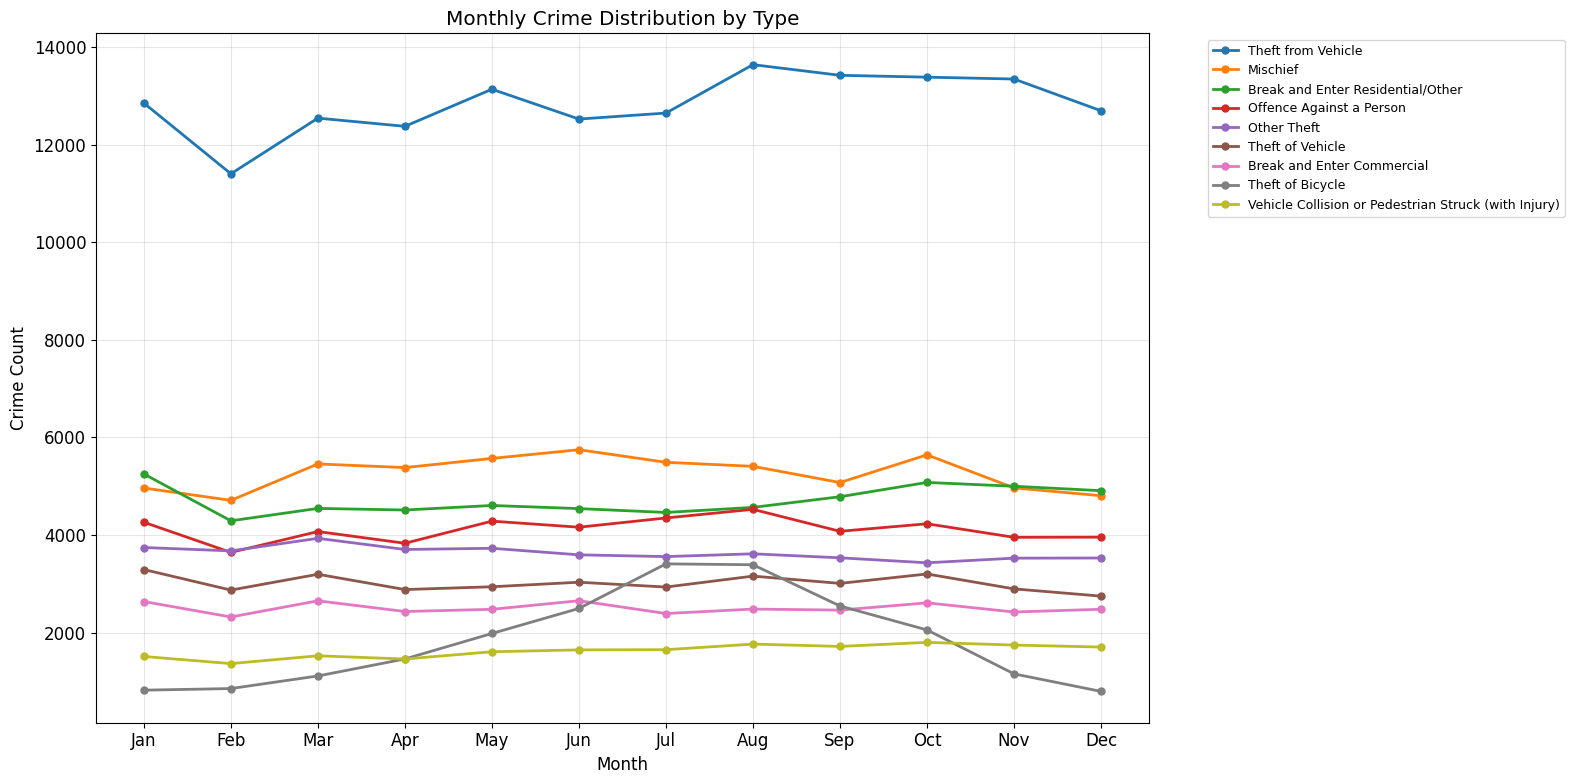

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

monthly_type = train.groupby(['MONTH', 'TYPE']).size().reset_index(name='Count')
for crime_type in type_counts.index:
    subset = monthly_type[monthly_type['TYPE'] == crime_type]
    ax.plot(subset['MONTH'], subset['Count'], marker='o', linewidth=2,
            label=crime_type, markersize=5)

ax.set_xlabel('Month'); ax.set_ylabel('Count')
ax.set_title('Monthly Distribution by Crime Type')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(month_names)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Chart 6: Hourly Crime Heatmap (Hour x Type)

Property crimes like Theft from Vehicle and Break and Enter cluster in the evening (roughly 18:00-23:00). Vehicle collisions show the classic commute-hour peaks around 8am and 5pm. Mischief concentrates late at night. Offence Against a Person has a heavy bar at hour -1 (the sentinel for missing time data) which confirms the missing HOUR values are all from this category. For the monthly forecasting model, this hourly view is background context rather than a direct input.

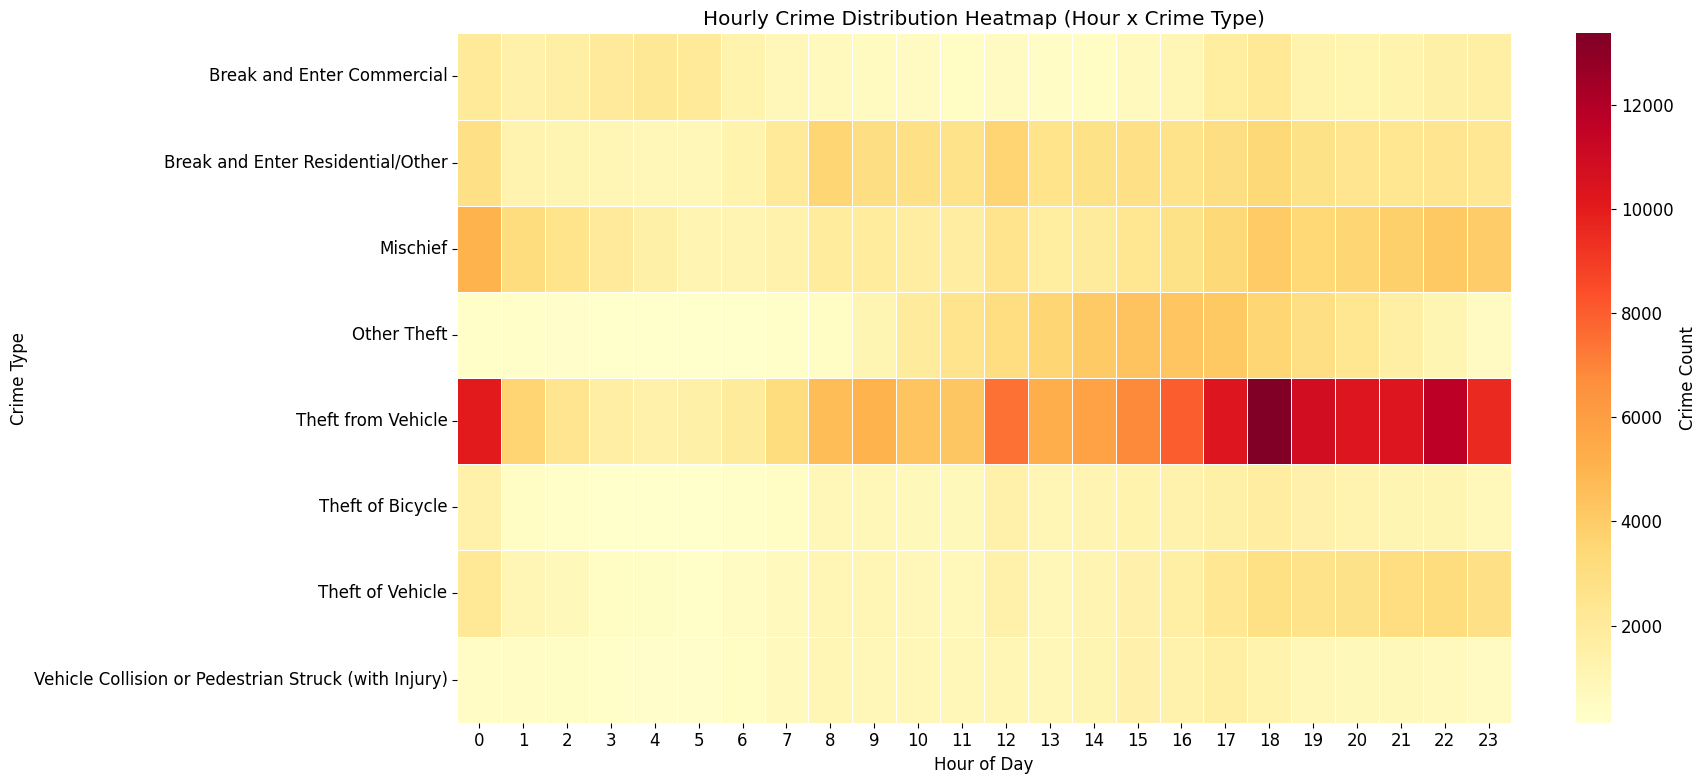

In [ ]:
fig, ax = plt.subplots(figsize=(18, 8))

hourly_data = train[train['HOUR'] >= 0]
hourly_type = hourly_data.groupby(['HOUR', 'TYPE']).size().reset_index(name='Count')
heatmap_data = hourly_type.pivot(index='TYPE', columns='HOUR', values='Count').fillna(0)

sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Hourly Crime Heatmap (Hour x Type)')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Crime Type')

plt.tight_layout()
plt.show()

### Chart 7: Top 15 Neighbourhoods by Crime Count

The Central Business District accounts for far more incidents than any other neighbourhood — unsurprising given it's the densest, most trafficked area in Vancouver. West End, Mount Pleasant, and Kitsilano round out the top spots. These five areas together make up a disproportionate share of total crime. The model doesn't use neighbourhood as a feature (we aggregate by type, not by area) but this gives useful spatial context.

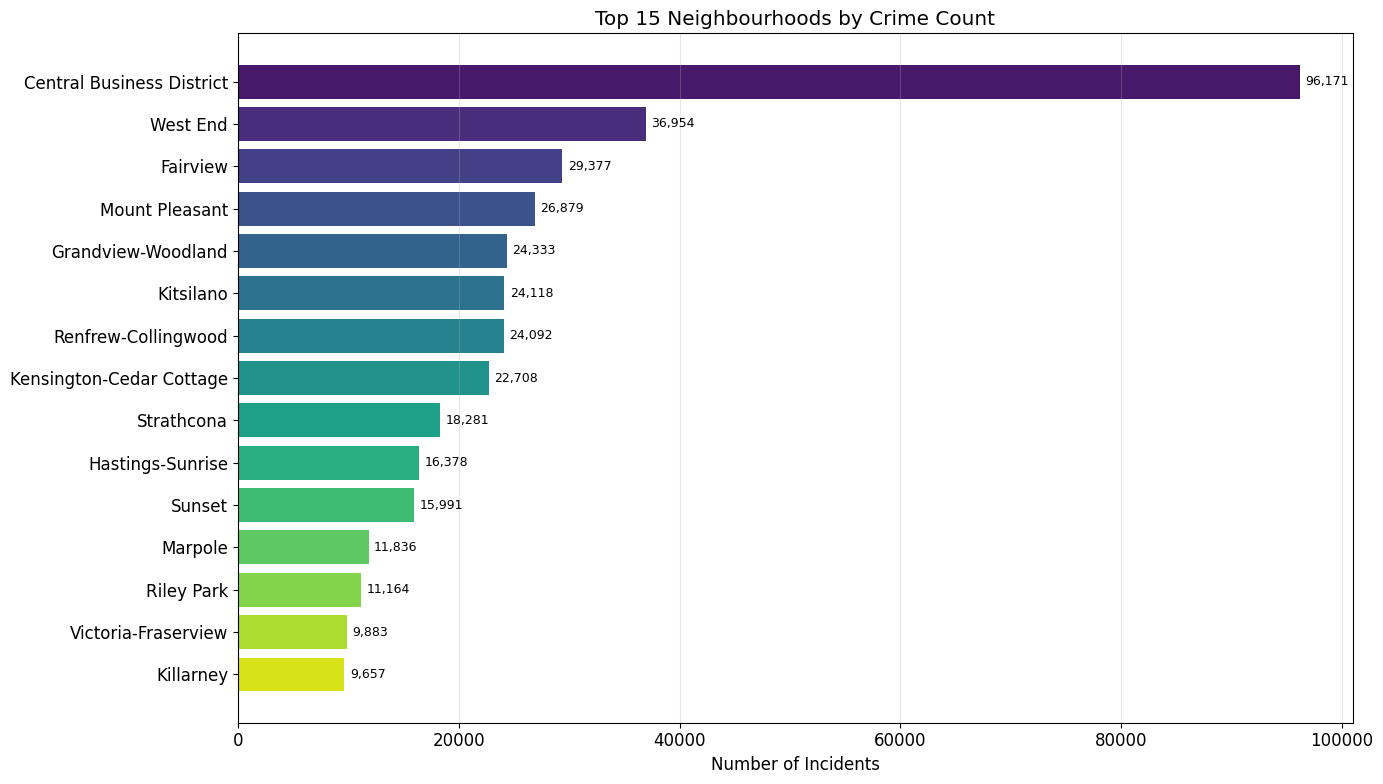

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

neighbourhood_counts = (train[train['NEIGHBOURHOOD'] != 'Unknown']['NEIGHBOURHOOD']
                        .value_counts().head(15))
colors_nb = sns.color_palette('viridis', n_colors=15)

bars = ax.barh(neighbourhood_counts.index[::-1], neighbourhood_counts.values[::-1],
               color=colors_nb[::-1])
ax.set_xlabel('Incidents'); ax.set_title('Top 15 Neighbourhoods by Crime Count')

for b in bars:
    w = b.get_width()
    ax.text(w + 500, b.get_y() + b.get_height()/2, f'{int(w):,}', va='center', fontsize=9)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 8: Spatial Scatter Plot (Lat/Lon)

The scatter confirms what the neighbourhood analysis suggests: the densest crime cluster is in downtown Vancouver (north-central in the map). There are secondary clusters along the main commercial corridors heading east and south. Theft from Vehicle points are scattered across the entire city footprint while Break and Enter shows tighter residential clustering. The city boundary is clearly visible from where the data points stop.

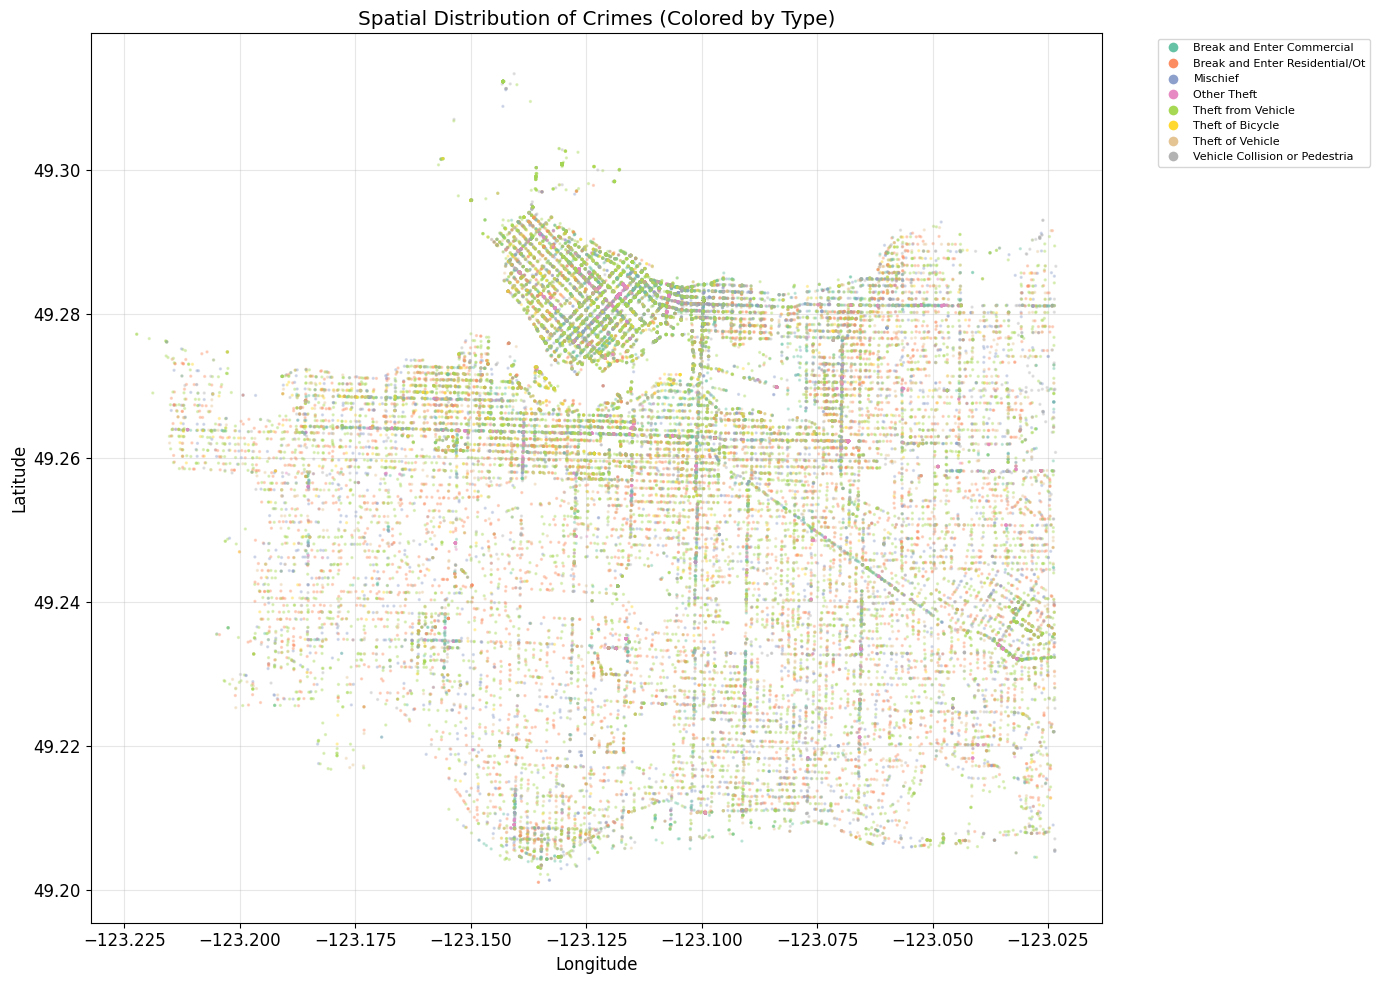

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

sample = train.sample(min(50000, len(train)), random_state=42)
sample_valid = sample[(sample['Latitude'] != 0) & (sample['Longitude'] != 0)]

ax.scatter(sample_valid['Longitude'], sample_valid['Latitude'],
           c=sample_valid['TYPE'].astype('category').cat.codes,
           cmap='Set2', alpha=0.3, s=2)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Spatial Crime Distribution (coloured by type)')

crime_types_list = sample_valid['TYPE'].astype('category').cat.categories.tolist()
handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=plt.cm.Set2(i/len(crime_types_list)),
           markersize=8, label=ct[:30])
           for i, ct in enumerate(crime_types_list)]
ax.legend(handles=handles, bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Chart 8b: GeoPandas — Crime Density by Neighbourhood

GeoPandas lets us move from a raw scatter of coordinates to actual neighbourhood polygons. Here we use convex-hull approximations per neighbourhood and shade them by total crime count, giving a proper choropleth view. The downtown cluster becomes immediately obvious as one solid dark region rather than a cloud of points.

In [ ]:
try:
    import geopandas as gpd
    from shapely.geometry import Point

    # Build GeoDataFrame from train coordinates
    geo_train = train[(train['Latitude'] != 0) & (train['Longitude'] != 0)].copy()
    geometry  = [Point(xy) for xy in zip(geo_train['Longitude'], geo_train['Latitude'])]
    gdf       = gpd.GeoDataFrame(geo_train, geometry=geometry, crs='EPSG:4326')

    # Aggregate crime count per neighbourhood (excluding Unknown)
    nb_counts = (gdf[gdf['NEIGHBOURHOOD'] != 'Unknown']
                 .groupby('NEIGHBOURHOOD')
                 .size()
                 .reset_index(name='Crime_Count'))

    # Create a simple convex-hull cluster map per neighbourhood
    nb_hulls = (gdf[gdf['NEIGHBOURHOOD'] != 'Unknown']
                .groupby('NEIGHBOURHOOD')['geometry']
                .apply(lambda g: g.unary_union.convex_hull)
                .reset_index())
    nb_hulls.columns = ['NEIGHBOURHOOD', 'geometry']
    nb_gdf = gpd.GeoDataFrame(
        nb_hulls.merge(nb_counts, on='NEIGHBOURHOOD'),
        geometry='geometry', crs='EPSG:4326'
    )

    fig, ax = plt.subplots(figsize=(14, 10))
    nb_gdf.plot(column='Crime_Count', cmap='YlOrRd', legend=True,
                legend_kwds={'label': 'Crime Count', 'orientation': 'vertical'},
                edgecolor='grey', linewidth=0.4, alpha=0.8, ax=ax)

    ax.set_title('Crime Density by Neighbourhood (GeoPandas Choropleth)')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"GeoDataFrame built: {nb_gdf.shape[0]} neighbourhoods plotted.")

except ImportError:
    print("geopandas not installed. Run: pip install geopandas shapely")
    print("Showing fallback neighbourhood bar chart instead.")

    fig, ax = plt.subplots(figsize=(14, 6))
    nb_counts_fb = (train[train['NEIGHBOURHOOD'] != 'Unknown']['NEIGHBOURHOOD']
                    .value_counts().head(20))
    nb_counts_fb.sort_values().plot(kind='barh', ax=ax, color='#e74c3c', alpha=0.8)
    ax.set_title('Crime Count by Neighbourhood (top 20)')
    ax.set_xlabel('Count')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

### Chart 9: Day of Week Distribution

Crime is fairly consistent across weekdays, with Friday and Saturday edging slightly higher. The weekly pattern is much weaker than the monthly or hourly patterns seen earlier. For a monthly forecasting model this doesn't add much — the day-of-week signal averages out over a month. It's included here for completeness and for any future daily-level modelling.

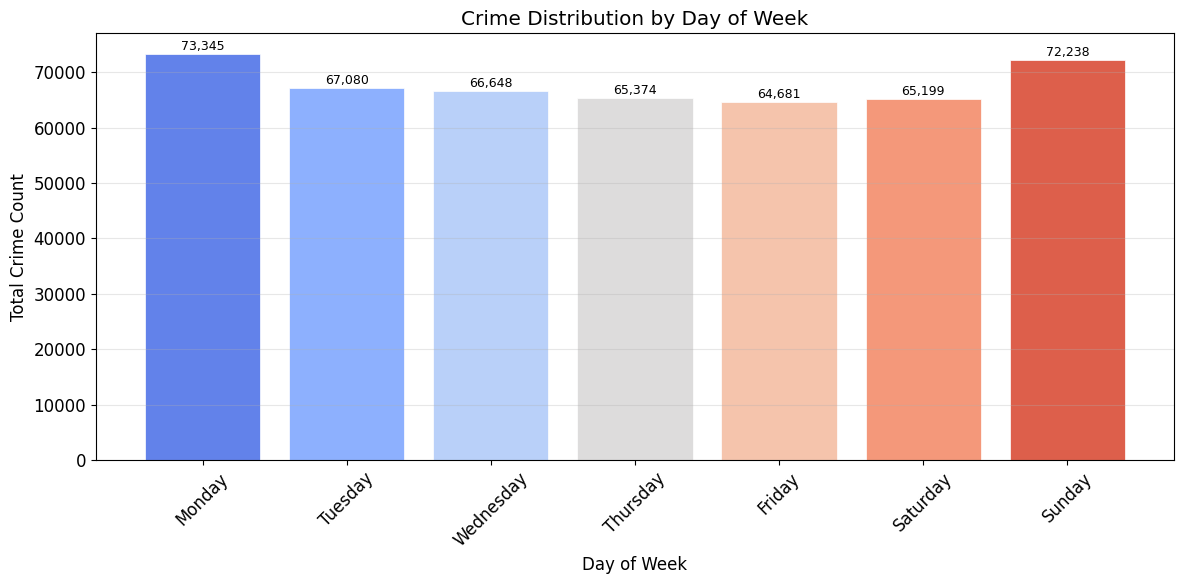

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

train['Date'] = pd.to_datetime(train['Date'], errors='coerce')
train['DAY_OF_WEEK'] = train['Date'].dt.dayofweek

day_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = train['DAY_OF_WEEK'].value_counts().sort_index()

bars = ax.bar(range(7), day_counts.values,
              color=sns.color_palette('coolwarm', 7), edgecolor='white', linewidth=0.5)
ax.set_xticks(range(7)); ax.set_xticklabels(day_names, rotation=45)
ax.set_xlabel('Day of Week'); ax.set_ylabel('Total Crimes')
ax.set_title('Crime Distribution by Day of Week')
ax.grid(axis='y', alpha=0.3)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2., h + 200, f'{int(h):,}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Chart 10: Crime Type Composition in Top 5 Neighbourhoods

The CBD has a notably different crime mix from residential neighbourhoods — heavy on Theft from Vehicle and Mischief (typical commercial district profile). Residential areas like Kitsilano and Mount Pleasant have more Break and Enter Residential. Each neighbourhood has its own profile, which supports neighbourhood-level resource allocation even if our model doesn't forecast at that granularity.

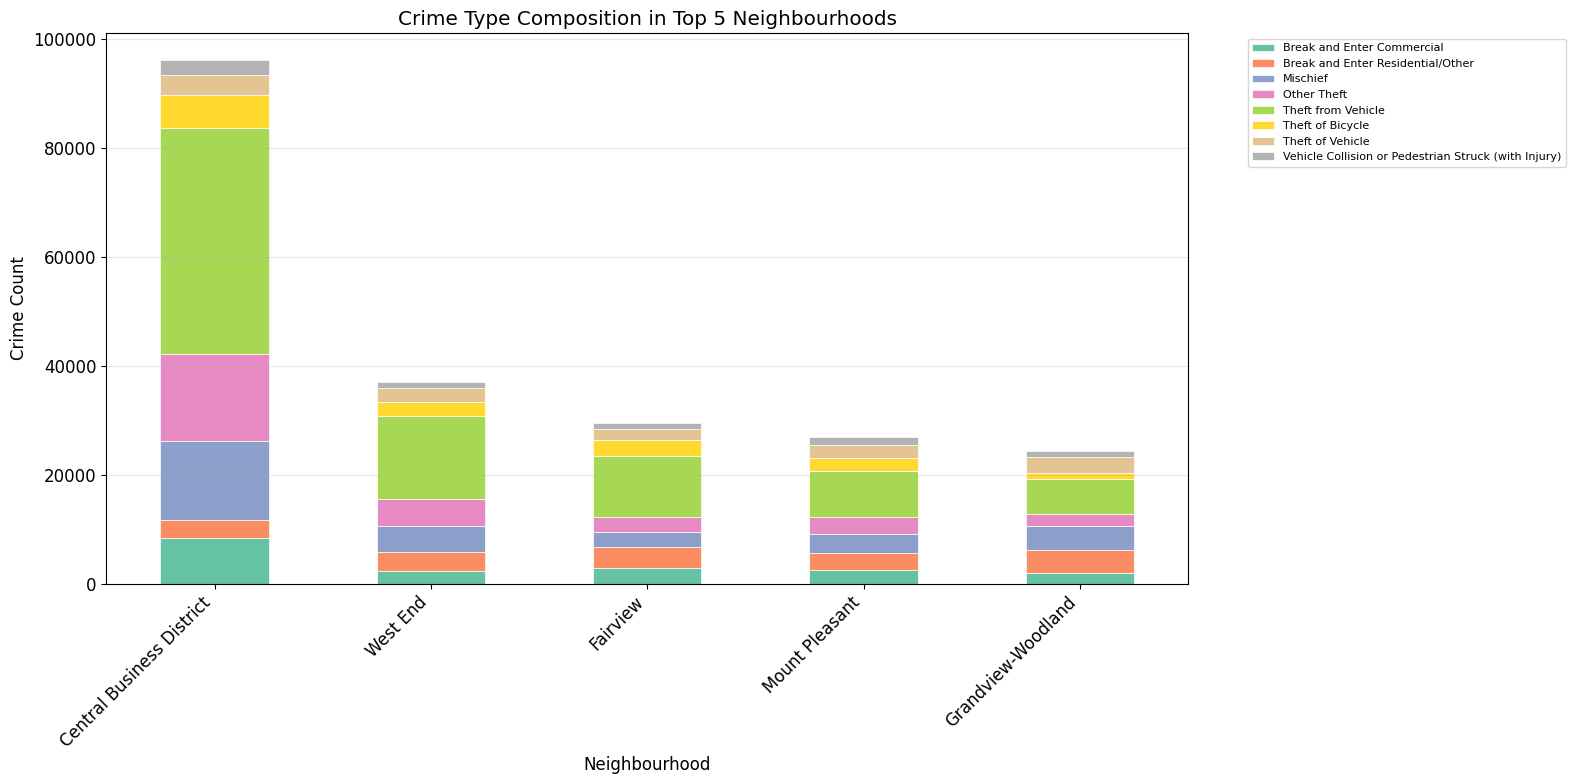

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

top5_nb = (train[train['NEIGHBOURHOOD'] != 'Unknown']['NEIGHBOURHOOD']
           .value_counts().head(5).index.tolist())
top5_data = train[train['NEIGHBOURHOOD'].isin(top5_nb)]

crosstab = pd.crosstab(top5_data['NEIGHBOURHOOD'], top5_data['TYPE'])
crosstab.loc[top5_nb].plot(kind='bar', stacked=True, ax=ax,
                            colormap='Set2', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Neighbourhood'); ax.set_ylabel('Count')
ax.set_title('Crime Mix in Top 5 Neighbourhoods')
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Chart 11: Hourly Distribution Violin Plot

The violin plots show that most crime types have a wide spread across hours rather than concentrating at a single time. Theft from Vehicle is notably skewed toward evening/night. Vehicle Collision is more symmetric, peaking around commute hours. The width at different hour values shows how spread out each type's timing is — wider = more dispersed across the day.

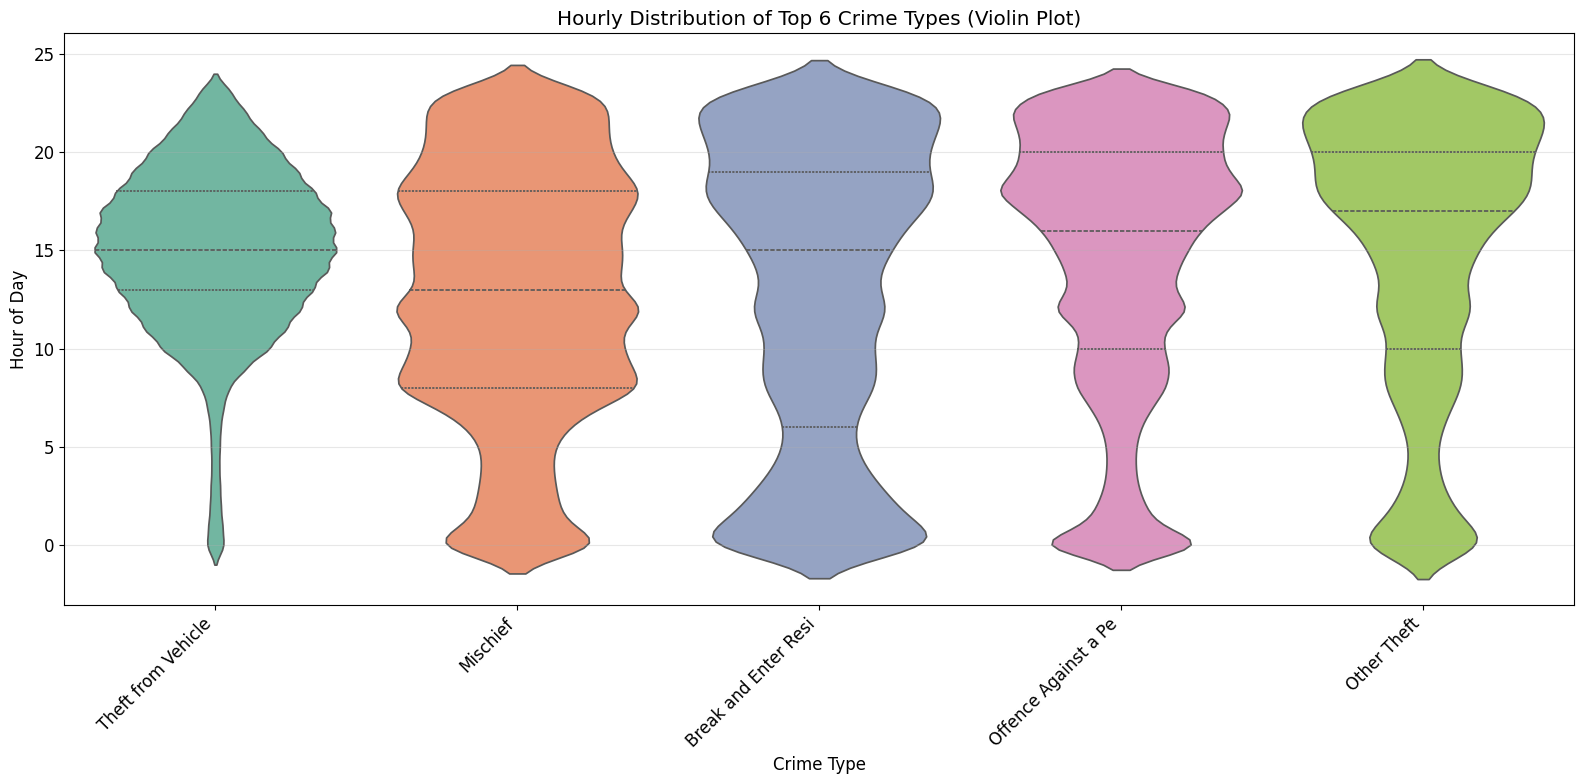

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

hourly_valid = train[train['HOUR'] >= 0][['TYPE', 'HOUR']]
top6_types   = type_counts.index[:6].tolist()
hourly_top6  = hourly_valid[hourly_valid['TYPE'].isin(top6_types)]

sns.violinplot(x='TYPE', y='HOUR', data=hourly_top6, palette='Set2',
               inner='quartile', ax=ax)
ax.set_xticklabels([t[:20] for t in top6_types], rotation=45, ha='right')
ax.set_xlabel('Crime Type'); ax.set_ylabel('Hour')
ax.set_title('Hour Distribution - Top 6 Crime Types')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Chart 12: Year x Month Heatmap

The summer peaks (brighter cells in months 6-8) are consistent across all 13 years, confirming that the seasonal pattern is stable and not an artefact of a specific period. The early 2000s rows are slightly darker overall (more crime), matching the trend chart. No anomalous months stand out, which is a good sign for a forecasting model — the patterns the model learns from 1999-2010 should generalise to 2011 and beyond.

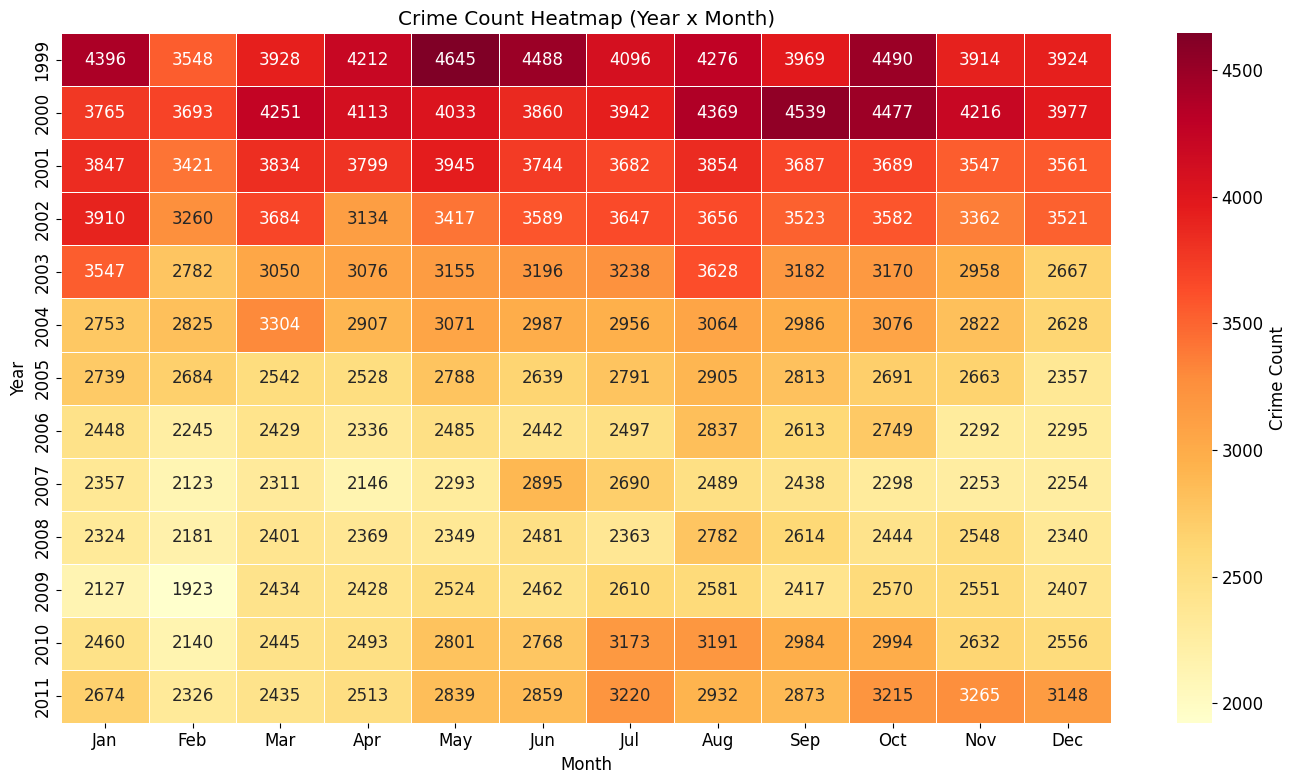

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

year_month = train.groupby(['YEAR','MONTH']).size().reset_index(name='Count')
heatmap_ym = year_month.pivot(index='YEAR', columns='MONTH', values='Count').fillna(0)
heatmap_ym.columns = month_names

sns.heatmap(heatmap_ym, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Crime Count Heatmap (Year x Month)')
ax.set_xlabel('Month'); ax.set_ylabel('Year')

plt.tight_layout()
plt.show()

### Chart 13: Time Series Decomposition — Theft from Vehicle

Breaking the Theft from Vehicle series into trend, seasonal, and residual components shows a clear downward trend from 1999 to ~2005 that then flattens. The seasonal component has a consistent annual cycle with summer highs. The residuals are small relative to the trend and seasonal signal, meaning most of the variance is explained. This validates the lag and seasonal features we'll build.

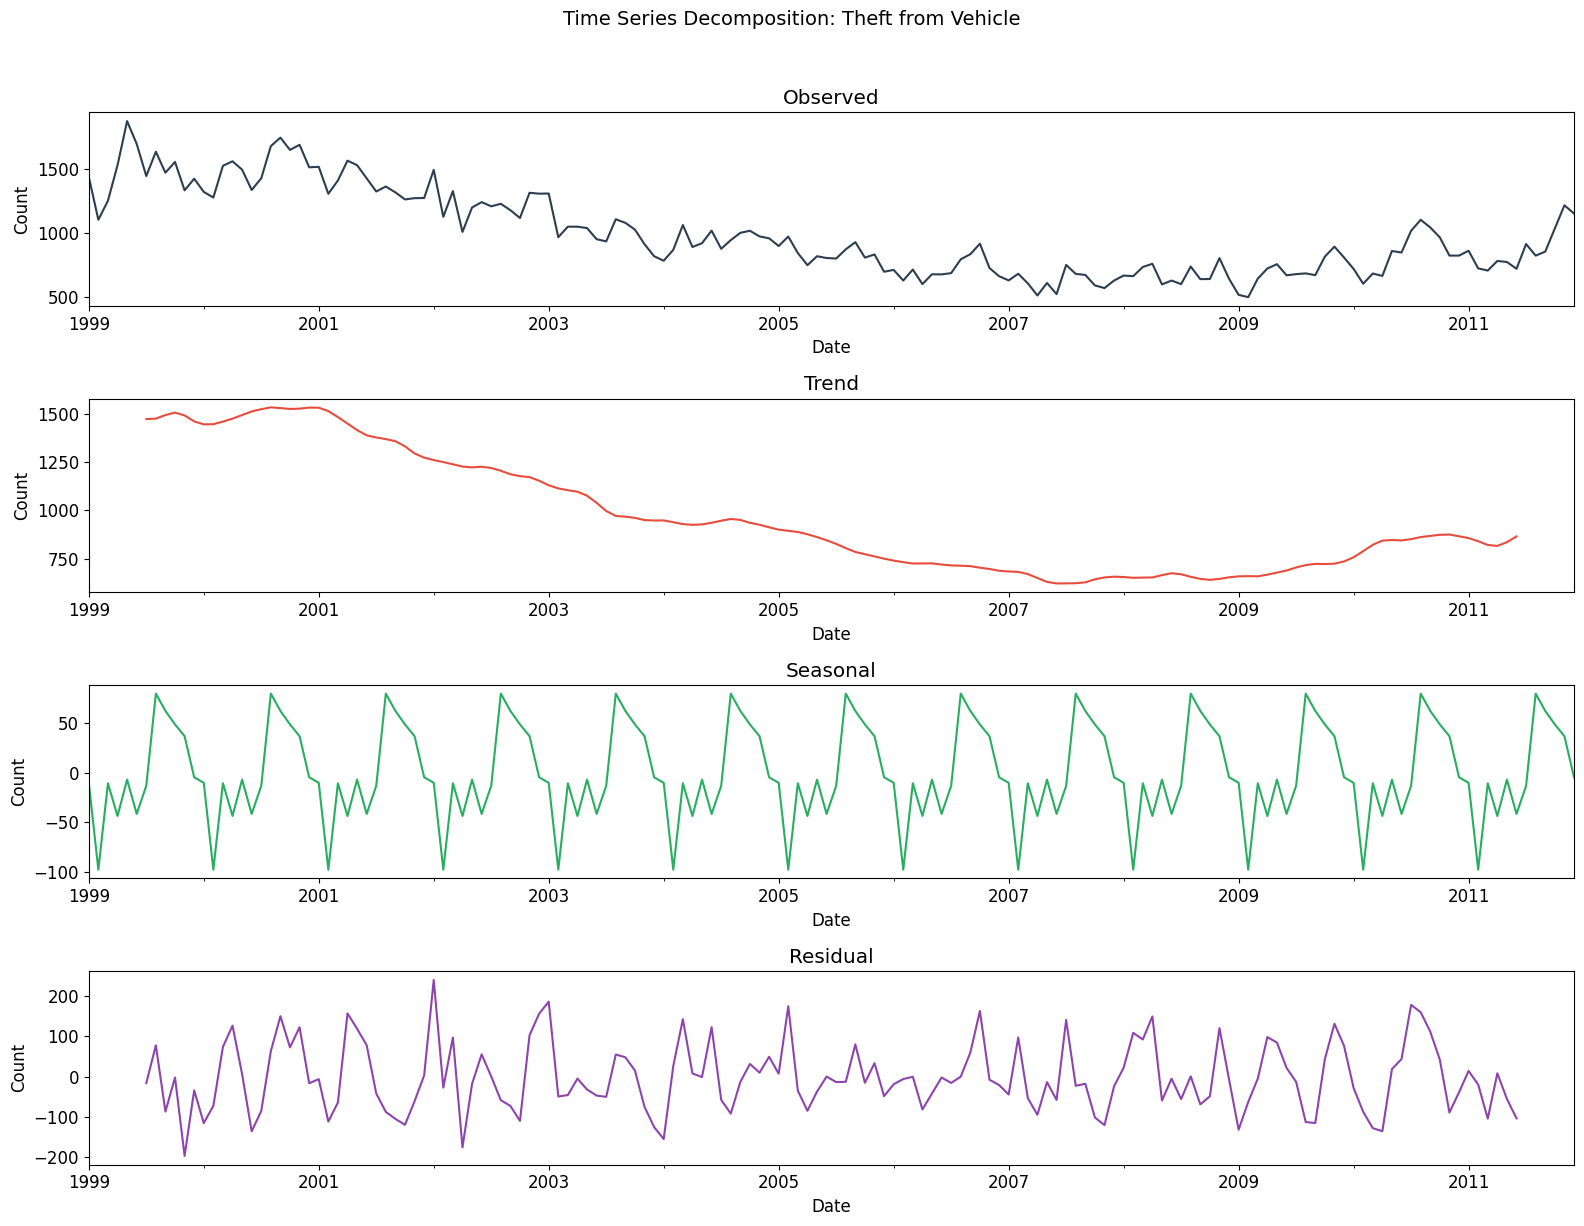

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

tfv = train[train['TYPE'] == 'Theft from Vehicle'].copy()
tfv_monthly = tfv.groupby(['YEAR','MONTH']).size().reset_index(name='Count')
tfv_monthly['Date'] = pd.to_datetime(tfv_monthly[['YEAR','MONTH']].assign(DAY=1))
tfv_ts = tfv_monthly.set_index('Date').sort_index()['Count']

try:
    decomp = seasonal_decompose(tfv_ts, model='additive', period=12)
    for ax_i, (comp, label, col) in zip(axes, [
            (decomp.observed, 'Observed',  '#2c3e50'),
            (decomp.trend,    'Trend',     '#e74c3c'),
            (decomp.seasonal, 'Seasonal',  '#27ae60'),
            (decomp.resid,    'Residual',  '#8e44ad')]):
        comp.plot(ax=ax_i, color=col)
        ax_i.set_title(label); ax_i.set_ylabel('Count')
except Exception as e:
    print(f"Decomposition failed: {e}")

plt.suptitle('Decomposition: Theft from Vehicle', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Chart 14: Correlation Heatmap

X/Y and Latitude/Longitude are essentially redundant — perfect correlation since they encode the same location in different coordinate systems. Only one set needs to go into the model. YEAR has a weak negative correlation with the numerical features, consistent with the declining crime trend. HOUR and MINUTE show almost no correlation with spatial features, as expected.

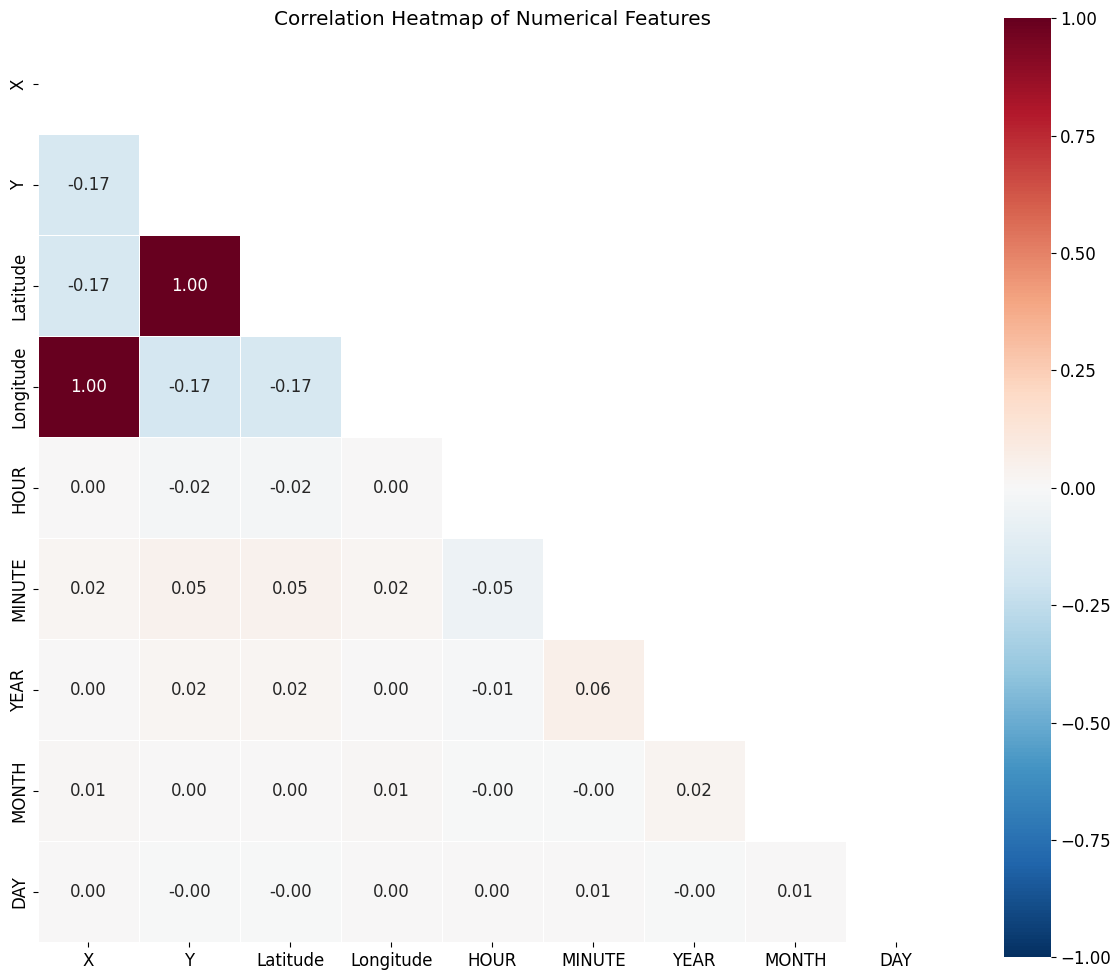

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

numeric_cols = ['X','Y','Latitude','Longitude','HOUR','MINUTE','YEAR','MONTH','DAY']
corr_matrix  = train[train['HOUR'] >= 0][numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap - Numerical Features')

plt.tight_layout()
plt.show()

### Chart 15: Box Plots — Monthly Counts per Crime Type

Theft from Vehicle has the highest median monthly count and widest spread (~600-1400 range). Theft of Bicycle shows a wide IQR and significant outliers — driven by strong seasonality. Vehicle Collision and Offence Against a Person are tighter distributions with fewer extreme values. Understanding per-type variance is useful when evaluating model error — a 50-count RMSE means something very different for a high-volume type vs a low-volume one.

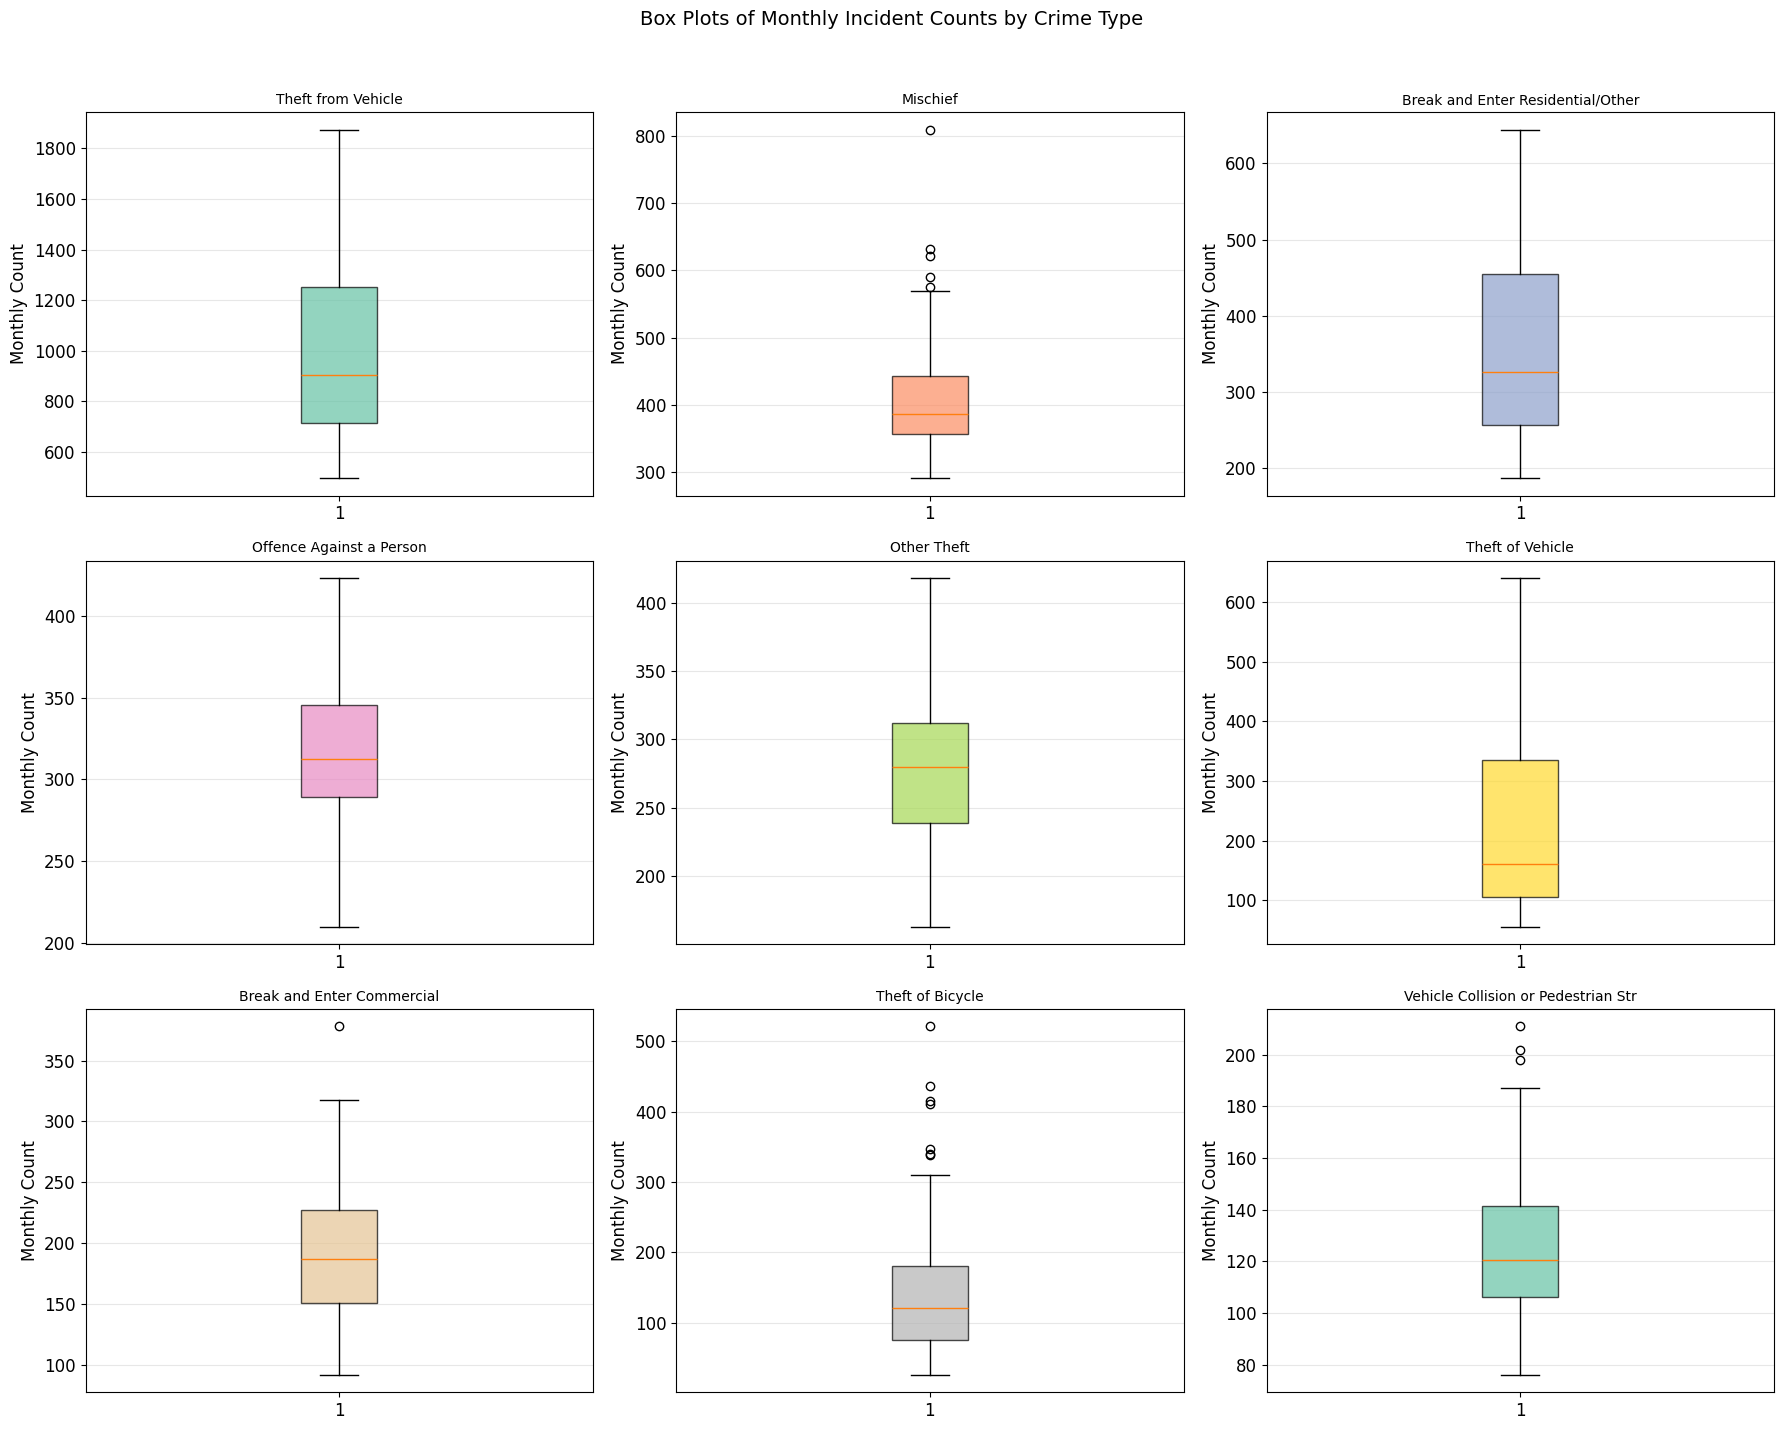

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
crime_types_all = type_counts.index.tolist()

for idx, crime_type in enumerate(crime_types_all):
    row_i, col_i = idx // 3, idx % 3
    ax = axes[row_i][col_i]
    monthly_ct = (train[train['TYPE'] == crime_type]
                  .groupby(['YEAR','MONTH']).size().reset_index(name='Count'))
    ax.boxplot(monthly_ct['Count'], patch_artist=True,
               boxprops=dict(facecolor=sns.color_palette('Set2')[idx % 8], alpha=0.7))
    ax.set_title(crime_type[:35], fontsize=10)
    ax.set_ylabel('Monthly Count')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Monthly Count Distribution by Crime Type', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

---
# Section 5: Hypothesis Testing

### Hypothesis 1: Summer vs Winter Crime Counts (T-Test)

**H0:** There is no significant difference in monthly crime counts between summer (Jun-Aug) and winter (Dec-Feb).

**H1:** There is a significant difference in monthly crime counts between summer and winter.

In [ ]:
monthly_all   = train.groupby(['YEAR','MONTH']).size().reset_index(name='Count')
summer_counts = monthly_all[monthly_all['MONTH'].isin([6,7,8])]['Count'].values
winter_counts = monthly_all[monthly_all['MONTH'].isin([12,1,2])]['Count'].values

print(f"Summer  Mean={summer_counts.mean():.2f}  Std={summer_counts.std():.2f}  N={len(summer_counts)}")
print(f"Winter  Mean={winter_counts.mean():.2f}  Std={winter_counts.std():.2f}  N={len(winter_counts)}")

t_stat, p_value = ttest_ind(summer_counts, winter_counts, equal_var=False)
print(f"\nWelch t = {t_stat:.4f},  p = {p_value:.6f}")
print("Reject H0." if p_value < 0.05 else "Fail to reject H0.")

Summer months - Mean: 3176.38, Std: 587.17, N: 39
Winter months - Mean: 2875.21, Std: 658.67, N: 39

T-statistic: 2.1041
P-value: 0.038724

Conclusion: Reject H0 (p=0.038724 < 0.05). There IS a statistically significant difference.
Summer months have significantly higher crime counts than winter months.


### Hypothesis 2: Theft from Vehicle vs Theft of Bicycle (Mann-Whitney U Test)

**H0:** There is no significant difference in monthly incident counts between Theft from Vehicle and Theft of Bicycle.

**H1:** There is a significant difference in monthly incident counts between these two crime types.

In [ ]:
tfv_m = train[train['TYPE']=='Theft from Vehicle'].groupby(['YEAR','MONTH']).size().values
tob_m = train[train['TYPE']=='Theft of Bicycle'].groupby(['YEAR','MONTH']).size().values

print(f"Theft from Vehicle  Mean={tfv_m.mean():.2f}  Median={np.median(tfv_m):.2f}")
print(f"Theft of Bicycle    Mean={tob_m.mean():.2f}  Median={np.median(tob_m):.2f}")

u_stat, p_value = mannwhitneyu(tfv_m, tob_m, alternative='two-sided')
print(f"\nMann-Whitney U={u_stat:.4f},  p={p_value:.6e}")
print("Reject H0." if p_value < 0.05 else "Fail to reject H0.")

Theft from Vehicle - Mean: 986.74, Median: 904.00
Theft of Bicycle   - Mean: 141.73, Median: 121.00

Mann-Whitney U statistic: 24332.5000
P-value: 1.255260e-52

Conclusion: Reject H0 (p=1.255260e-52 < 0.05). There IS a significant difference.
Theft from Vehicle has significantly different (higher) monthly counts than Theft of Bicycle.


### Hypothesis 3: Crime Counts Across Top 5 Neighbourhoods (ANOVA)

**H0:** The mean monthly crime counts are equal across the top 5 neighbourhoods.

**H1:** At least one neighbourhood has a significantly different mean monthly crime count.

In [ ]:
top5_nb_names = (train[train['NEIGHBOURHOOD'] != 'Unknown']['NEIGHBOURHOOD']
                 .value_counts().head(5).index.tolist())

groups = []
for nb in top5_nb_names:
    monthly_nb = train[train['NEIGHBOURHOOD']==nb].groupby(['YEAR','MONTH']).size().values
    groups.append(monthly_nb)
    print(f"{nb:35s}  Mean={monthly_nb.mean():.2f}  Std={monthly_nb.std():.2f}")

f_stat, p_value = f_oneway(*groups)
print(f"\nANOVA: F={f_stat:.4f},  p={p_value:.6e}")
print("Reject H0." if p_value < 0.05 else "Fail to reject H0.")

Top 5 Neighbourhoods: ['Central Business District', 'West End', 'Fairview', 'Mount Pleasant', 'Grandview-Woodland']

Central Business District           - Mean: 616.48, Std: 137.62
West End                            - Mean: 236.88, Std: 77.66
Fairview                            - Mean: 188.31, Std: 58.54
Mount Pleasant                      - Mean: 172.30, Std: 39.39
Grandview-Woodland                  - Mean: 155.98, Std: 49.12

F-statistic: 899.7638
P-value: 1.847976e-289

Conclusion: Reject H0 (p=1.847976e-289 < 0.05).
At least one neighbourhood has a significantly different mean monthly crime count.


---
# Section 6: Feature Engineering and Data Preparation

### 6.1 Missing Values (handled in Section 3)

- HUNDRED_BLOCK: 13 missing → 'Unknown'
- NEIGHBOURHOOD: ~51K missing → 'Unknown'
- HOUR/MINUTE: ~49K missing → -1 sentinel

All 474,565 rows retained.

### 6.2 Outlier Detection

In [ ]:
monthly_per_type = train.groupby(['YEAR','MONTH','TYPE']).size().reset_index(name='Incident_Count')

for crime_type in crime_types_all:
    ct = monthly_per_type[monthly_per_type['TYPE']==crime_type]['Incident_Count']
    Q1, Q3 = ct.quantile(0.25), ct.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ct[(ct < Q1 - 1.5*IQR) | (ct > Q3 + 1.5*IQR)]
    print(f"{crime_type[:40]:40s}  IQR={IQR:6.1f}  Outliers={len(outliers)}")

# not removing — these reflect real seasonal/event spikes

OUTLIER DETECTION (IQR Method on Monthly Counts)
Theft from Vehicle                       | Q1:   716.8 | Q3:  1253.5 | IQR:   536.8 | Outliers: 0
Mischief                                 | Q1:   356.8 | Q3:   443.2 | IQR:    86.5 | Outliers: 5
Break and Enter Residential/Other        | Q1:   256.8 | Q3:   455.2 | IQR:   198.5 | Outliers: 0
Offence Against a Person                 | Q1:   289.0 | Q3:   345.2 | IQR:    56.2 | Outliers: 0
Other Theft                              | Q1:   238.8 | Q3:   312.2 | IQR:    73.5 | Outliers: 0
Theft of Vehicle                         | Q1:   104.8 | Q3:   335.5 | IQR:   230.8 | Outliers: 0
Break and Enter Commercial               | Q1:   151.0 | Q3:   227.0 | IQR:    76.0 | Outliers: 1
Theft of Bicycle                         | Q1:    75.8 | Q3:   180.2 | IQR:   104.5 | Outliers: 7
Vehicle Collision or Pedestrian Struck ( | Q1:   106.0 | Q3:   141.2 | IQR:    35.2 | Outliers: 3

Note: Outliers in monthly counts are typically driven by genuine sea

### 6.3 Categorical Encoding

In [ ]:
le_type = LabelEncoder()
train['TYPE_encoded'] = le_type.fit_transform(train['TYPE'])

for i, cls in enumerate(le_type.classes_):
    print(f"  {i} -> {cls}")

Label Encoding for TYPE:
  0 -> Break and Enter Commercial
  1 -> Break and Enter Residential/Other
  2 -> Mischief
  3 -> Offence Against a Person
  4 -> Other Theft
  5 -> Theft from Vehicle
  6 -> Theft of Bicycle
  7 -> Theft of Vehicle
  8 -> Vehicle Collision or Pedestrian Struck (with Injury)


### 6.4 Feature Manipulation: Aggregate to Monthly and Create Features

In [ ]:
monthly_df = (train.groupby(['YEAR','MONTH','TYPE','TYPE_encoded'])
              .size().reset_index(name='Incident_Count'))
monthly_df['Date'] = pd.to_datetime(monthly_df[['YEAR','MONTH']].assign(DAY=1))
monthly_df = monthly_df.sort_values(['TYPE','Date']).reset_index(drop=True)

print(f"monthly_df: {monthly_df.shape}")
print(f"Date range: {monthly_df['Date'].min()} to {monthly_df['Date'].max()}")
monthly_df.head(10)

Monthly aggregated dataset shape: (1404, 6)
Date range: 1999-01-01 00:00:00 to 2011-12-01 00:00:00

Sample:


,YEAR,MONTH,TYPE,TYPE_encoded,Incident_Count,Date
0,1999,1,Break and Enter Commercial,0,303,1999-01-01
1,1999,2,Break and Enter Commercial,0,254,1999-02-01
2,1999,3,Break and Enter Commercial,0,292,1999-03-01
3,1999,4,Break and Enter Commercial,0,266,1999-04-01
4,1999,5,Break and Enter Commercial,0,291,1999-05-01
5,1999,6,Break and Enter Commercial,0,306,1999-06-01
6,1999,7,Break and Enter Commercial,0,252,1999-07-01
7,1999,8,Break and Enter Commercial,0,241,1999-08-01
8,1999,9,Break and Enter Commercial,0,209,1999-09-01
9,1999,10,Break and Enter Commercial,0,306,1999-10-01


In [ ]:
def create_features(df):
    df = df.copy()
    df['Quarter']   = df['MONTH'].apply(lambda x: (x-1)//3 + 1)
    df['is_summer'] = df['MONTH'].isin([6,7,8]).astype(int)
    df['is_winter'] = df['MONTH'].isin([12,1,2]).astype(int)
    df['month_sin'] = np.sin(2 * np.pi * df['MONTH'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['MONTH'] / 12)

    for lag in [1, 2, 3, 6, 12]:
        df[f'lag_{lag}'] = df.groupby('TYPE_encoded')['Incident_Count'].shift(lag)

    for w in [3, 6, 12]:
        df[f'rolling_mean_{w}'] = df.groupby('TYPE_encoded')['Incident_Count'].transform(
            lambda x: x.shift(1).rolling(window=w, min_periods=1).mean()
        )
    return df

monthly_df       = create_features(monthly_df)
monthly_df_clean = monthly_df.dropna().reset_index(drop=True)

print(f"Shape after feature engineering: {monthly_df_clean.shape}")
print(monthly_df_clean.columns.tolist())

Shape after feature creation and NaN removal: (1296, 19)
Date range: 2000-01-01 00:00:00 to 2011-12-01 00:00:00

Features created:
['YEAR', 'MONTH', 'TYPE', 'TYPE_encoded', 'Incident_Count', 'Date', 'Quarter', 'is_summer', 'is_winter', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12']


### 6.5 Feature Selection

In [ ]:
feature_cols = ['TYPE_encoded','MONTH','YEAR','Quarter','is_summer','is_winter',
                'month_sin','month_cos','lag_1','lag_2','lag_3','lag_6','lag_12',
                'rolling_mean_3','rolling_mean_6','rolling_mean_12']
target_col = 'Incident_Count'

corr = (monthly_df_clean[feature_cols + [target_col]]
        .corr()[target_col].drop(target_col)
        .sort_values(ascending=False))
print("Feature correlation with target:")
for feat, v in corr.items():
    print(f"  {feat:25s}: {v:.4f}")

Number of features selected: 16

Selected features: ['TYPE_encoded', 'MONTH', 'YEAR', 'Quarter', 'is_summer', 'is_winter', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12']

Correlation with Incident_Count:
  lag_1                    : 0.9783
  rolling_mean_3           : 0.9755
  rolling_mean_12          : 0.9728
  rolling_mean_6           : 0.9706
  lag_2                    : 0.9674
  lag_12                   : 0.9597
  lag_3                    : 0.9562
  lag_6                    : 0.9438
  is_summer                : 0.0324
  Quarter                  : 0.0241
  MONTH                    : 0.0225
  month_cos                : -0.0250
  is_winter                : -0.0395
  month_sin                : -0.0437
  TYPE_encoded             : -0.0875
  YEAR                     : -0.1803


### 6.6 Data Transformation

No log or Box-Cox transform applied. Tree-based models (XGBoost, Random Forest) don't need the target to be normally distributed, and keeping counts on their original scale makes predictions interpretable. SARIMA is fitted per crime type on roughly-stationary monthly series, which are already well-behaved.

### 6.7 Data Scaling

In [ ]:
scaler = MinMaxScaler()
X_all        = monthly_df_clean[feature_cols].values
y_all        = monthly_df_clean[target_col].values
X_all_scaled = scaler.fit_transform(X_all)

print(f"X: {X_all_scaled.shape}  |  y: {y_all.shape}")

Feature matrix shape: (1296, 16)
Target vector shape: (1296,)

Scaled feature ranges (min, max):
  TYPE_encoded             : [0.0000, 1.0000]
  MONTH                    : [0.0000, 1.0000]
  YEAR                     : [0.0000, 1.0000]
  Quarter                  : [0.0000, 1.0000]
  is_summer                : [0.0000, 1.0000]
  is_winter                : [0.0000, 1.0000]
  month_sin                : [0.0000, 1.0000]
  month_cos                : [0.0000, 1.0000]
  lag_1                    : [0.0000, 1.0000]
  lag_2                    : [0.0000, 1.0000]
  lag_3                    : [0.0000, 1.0000]
  lag_6                    : [0.0000, 1.0000]
  lag_12                   : [0.0000, 1.0000]
  rolling_mean_3           : [0.0000, 1.0000]
  rolling_mean_6           : [0.0000, 1.0000]
  rolling_mean_12          : [0.0000, 1.0000]


### 6.8 Dimensionality Reduction

Not applied. With only 16 features there's no dimensionality problem to solve, and the lag/rolling features are all directly interpretable. Running PCA would remove that interpretability for no real gain.

### 6.9 Data Splitting (Time-Based)

In [ ]:
train_mask = monthly_df_clean['YEAR'] <= 2010
val_mask   = monthly_df_clean['YEAR'] == 2011

X_train, y_train = X_all_scaled[train_mask], y_all[train_mask]
X_val,   y_val   = X_all_scaled[val_mask],   y_all[val_mask]

print(f"Train: {X_train.shape[0]} rows  ({monthly_df_clean[train_mask]['Date'].min()} to {monthly_df_clean[train_mask]['Date'].max()})")
print(f"Val  : {X_val.shape[0]} rows  ({monthly_df_clean[val_mask]['Date'].min()} to {monthly_df_clean[val_mask]['Date'].max()})")

Training set: 1188 samples (2000-01-01 00:00:00 to 2010-12-01 00:00:00)
Validation set: 108 samples (2011-01-01 00:00:00 to 2011-12-01 00:00:00)

Target distribution:
  Train - Mean: 328.60, Std: 269.70
  Val   - Mean: 317.58, Std: 228.28


### 6.10 Class Imbalance

Not applicable — this is a regression problem predicting a continuous count, not a classification task. SMOTE and oversampling techniques don't apply here. The varying scale of counts across crime types (Theft from Vehicle ~1000/month vs Theft of Bicycle ~50/month) is handled by training one model with TYPE_encoded as a feature, letting it learn type-specific baselines.

---
# Section 7: Machine Learning Models

### 7.1 Model 1: XGBoost

In [ ]:
xgb_base = xgb.XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)
xgb_base.fit(X_train, y_train)
y_pred_base = xgb_base.predict(X_val)

rmse_base = np.sqrt(mean_squared_error(y_val, y_pred_base))
mae_base  = mean_absolute_error(y_val, y_pred_base)
r2_base   = r2_score(y_val, y_pred_base)
print(f"Base XGBoost  RMSE={rmse_base:.4f}  MAE={mae_base:.4f}  R2={r2_base:.4f}")

MODEL 1: XGBoost

Base XGBoost Results:
  RMSE: 56.1147
  MAE:  33.4455
  R2:   0.9396


In [ ]:
param_grid_xgb = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_grid_xgb, cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=0, n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

xgb_best   = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_val)

rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_val, y_pred_xgb)
r2_xgb   = r2_score(y_val, y_pred_xgb)

print(f"Best params : {xgb_grid.best_params_}")
print(f"CV RMSE     : {-xgb_grid.best_score_:.4f}")
print(f"Val         : RMSE={rmse_xgb:.4f}  MAE={mae_xgb:.4f}  R2={r2_xgb:.4f}")


Running GridSearchCV for XGBoost...
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV RMSE: 155.8783

Tuned XGBoost Validation Results:
  RMSE: 57.5485
  MAE:  35.4570
  R2:   0.9364


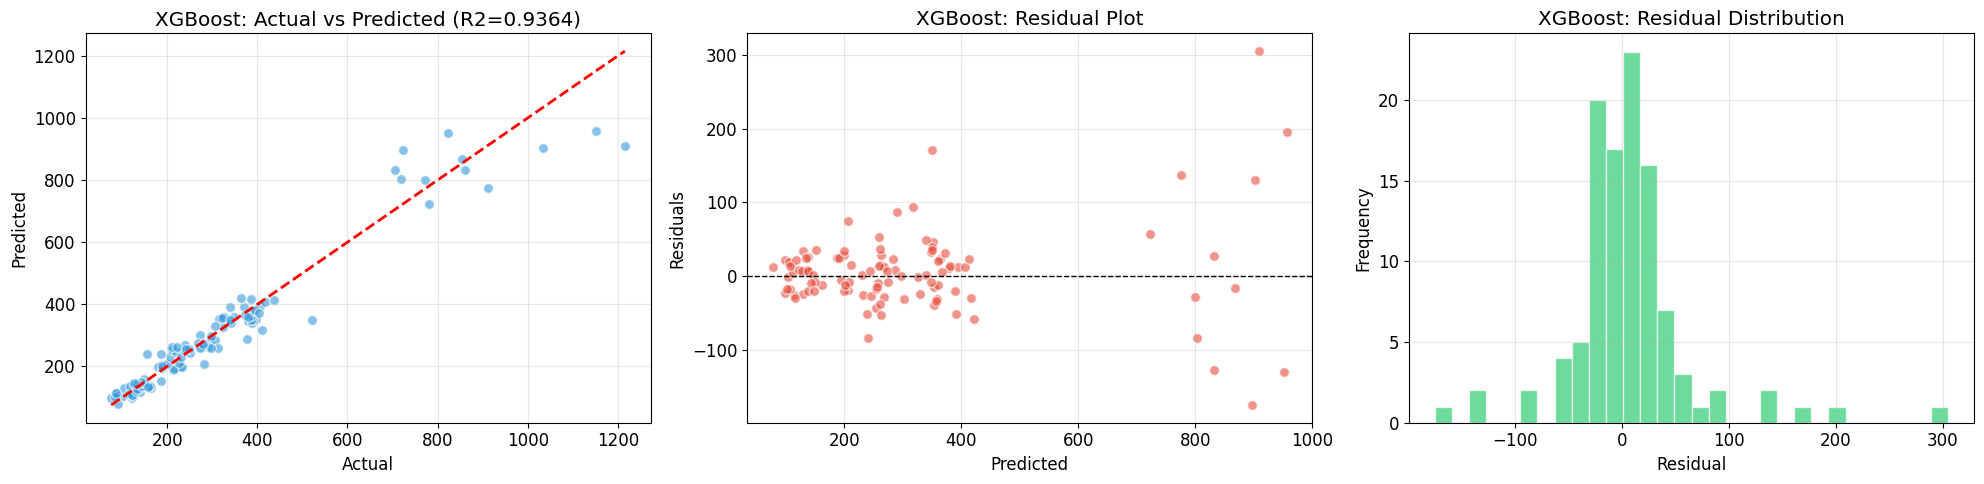

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

lo = min(y_val.min(), y_pred_xgb.min())
hi = max(y_val.max(), y_pred_xgb.max())

axes[0].scatter(y_val, y_pred_xgb, alpha=0.6, color='#3498db', edgecolors='white', s=50)
axes[0].plot([lo,hi],[lo,hi],'r--',linewidth=2)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'XGBoost: Actual vs Predicted  R2={r2_xgb:.4f}')
axes[0].grid(alpha=0.3)

res = y_val - y_pred_xgb
axes[1].scatter(y_pred_xgb, res, alpha=0.6, color='#e74c3c', edgecolors='white', s=50)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residuals')
axes[1].set_title('XGBoost Residuals')
axes[1].grid(alpha=0.3)

axes[2].hist(res, bins=30, color='#2ecc71', edgecolor='white', alpha=0.7)
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7.2 Model 2: Random Forest

In [ ]:
rf_base = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_split=5, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf_base.fit(X_train, y_train)
y_pred_rf_base = rf_base.predict(X_val)

rmse_rf_base = np.sqrt(mean_squared_error(y_val, y_pred_rf_base))
mae_rf_base  = mean_absolute_error(y_val, y_pred_rf_base)
r2_rf_base   = r2_score(y_val, y_pred_rf_base)
print(f"Base RF  RMSE={rmse_rf_base:.4f}  MAE={mae_rf_base:.4f}  R2={r2_rf_base:.4f}")

MODEL 2: Random Forest

Base Random Forest Results:
  RMSE: 62.6447
  MAE:  37.1639
  R2:   0.9247


In [ ]:
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [6, 8, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_dist_rf, n_iter=30, cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=0, random_state=42, n_jobs=-1
)
rf_random.fit(X_train, y_train)

rf_best   = rf_random.best_estimator_
y_pred_rf = rf_best.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
mae_rf  = mean_absolute_error(y_val, y_pred_rf)
r2_rf   = r2_score(y_val, y_pred_rf)

print(f"Best params : {rf_random.best_params_}")
print(f"CV RMSE     : {-rf_random.best_score_:.4f}")
print(f"Val         : RMSE={rmse_rf:.4f}  MAE={mae_rf:.4f}  R2={r2_rf:.4f}")


Running RandomizedSearchCV for Random Forest...
Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 8}
Best CV RMSE: 145.8356

Tuned Random Forest Validation Results:
  RMSE: 63.1115
  MAE:  37.2448
  R2:   0.9236


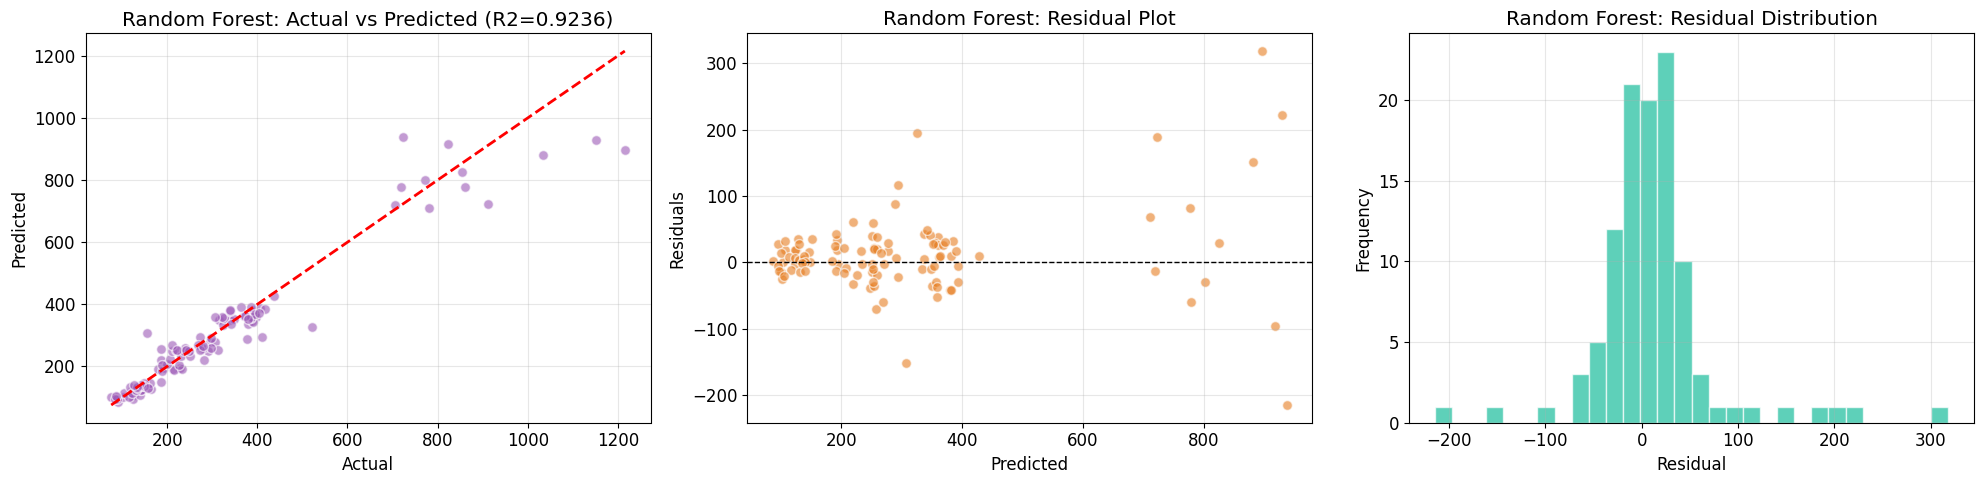

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

lo = min(y_val.min(), y_pred_rf.min())
hi = max(y_val.max(), y_pred_rf.max())

axes[0].scatter(y_val, y_pred_rf, alpha=0.6, color='#9b59b6', edgecolors='white', s=50)
axes[0].plot([lo,hi],[lo,hi],'r--',linewidth=2)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Random Forest: Actual vs Predicted  R2={r2_rf:.4f}')
axes[0].grid(alpha=0.3)

res_rf = y_val - y_pred_rf
axes[1].scatter(y_pred_rf, res_rf, alpha=0.6, color='#e67e22', edgecolors='white', s=50)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residuals')
axes[1].set_title('RF Residuals')
axes[1].grid(alpha=0.3)

axes[2].hist(res_rf, bins=30, color='#1abc9c', edgecolor='white', alpha=0.7)
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7.3 Model 3: SARIMA

In [ ]:
# Model 3: SARIMA - Per Crime Type
print("MODEL 3: SARIMA (per crime type)")

# Prepare monthly time series per crime type
monthly_ts = train.groupby(['YEAR', 'MONTH', 'TYPE']).size().reset_index(name='Count')
monthly_ts['Date'] = pd.to_datetime(monthly_ts[['YEAR', 'MONTH']].assign(DAY=1))

sarima_results = {}
sarima_predictions = {}

# SARIMA orders to try
orders_to_try = [(1, 1, 1), (1, 0, 1), (2, 1, 1), (0, 1, 1)]
seasonal_orders_to_try = [(1, 1, 1, 12), (0, 1, 1, 12), (1, 0, 1, 12)]

for crime_type in crime_types_all:
    print(f"\nFitting SARIMA for: {crime_type}")

    # Get time series for this crime type
    ct_ts = monthly_ts[monthly_ts['TYPE'] == crime_type].set_index('Date').sort_index()['Count']

    # Split: train up to 2010, validate on 2011
    ct_train = ct_ts[ct_ts.index.year <= 2010]
    ct_val = ct_ts[ct_ts.index.year == 2011]

    best_aic = np.inf
    best_model = None
    best_order = None
    best_seasonal = None

    # Manual grid search over orders
    for order in orders_to_try:
        for seasonal_order in seasonal_orders_to_try:
            try:
                model = SARIMAX(ct_train, order=order, seasonal_order=seasonal_order,
                                enforce_stationarity=False, enforce_invertibility=False)
                fitted = model.fit(disp=False, maxiter=200)
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_model = fitted
                    best_order = order
                    best_seasonal = seasonal_order
            except Exception:
                continue

    if best_model is not None:
        # Forecast validation period
        forecast = best_model.forecast(steps=len(ct_val))
        forecast = np.maximum(forecast, 0)  # Crime counts cannot be negative

        rmse_s = np.sqrt(mean_squared_error(ct_val.values, forecast.values))
        mae_s = mean_absolute_error(ct_val.values, forecast.values)

        sarima_results[crime_type] = {
            'order': best_order,
            'seasonal_order': best_seasonal,
            'aic': best_aic,
            'rmse': rmse_s,
            'mae': mae_s
        }
        sarima_predictions[crime_type] = forecast

        print(f"  Best order: {best_order}, Seasonal: {best_seasonal}")
        print(f"  AIC: {best_aic:.2f}, RMSE: {rmse_s:.2f}, MAE: {mae_s:.2f}")
    else:
        print(f"  SARIMA fitting failed for {crime_type}")

# Overall SARIMA performance
all_actuals = []
all_preds = []
for crime_type in sarima_predictions:
    ct_val = monthly_ts[(monthly_ts['TYPE'] == crime_type)].set_index('Date').sort_index()['Count']
    ct_val = ct_val[ct_val.index.year == 2011]
    all_actuals.extend(ct_val.values)
    all_preds.extend(sarima_predictions[crime_type].values)

rmse_sarima = np.sqrt(mean_squared_error(all_actuals, all_preds))
mae_sarima = mean_absolute_error(all_actuals, all_preds)
r2_sarima = r2_score(all_actuals, all_preds)

print(f"\nOverall SARIMA Validation Results:")
print(f"  RMSE: {rmse_sarima:.4f}")
print(f"  MAE:  {mae_sarima:.4f}")
print(f"  R2:   {r2_sarima:.4f}")

MODEL 3: SARIMA (per crime type)

Fitting SARIMA for: Theft from Vehicle


C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473:

  Best order: (1, 1, 1), Seasonal: (0, 1, 1, 12)
  AIC: 1438.20, RMSE: 148.13, MAE: 113.29

Fitting SARIMA for: Mischief


C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473:

  Best order: (1, 1, 1), Seasonal: (1, 1, 1, 12)
  AIC: 1299.61, RMSE: 32.66, MAE: 24.80

Fitting SARIMA for: Break and Enter Residential/Other


...

  Best order: (1, 1, 1), Seasonal: (0, 1, 1, 12)
  AIC: 1164.43, RMSE: 31.48, MAE: 26.47

Fitting SARIMA for: Theft of Bicycle


C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473:

  Best order: (1, 1, 1), Seasonal: (0, 1, 1, 12)
  AIC: 1139.62, RMSE: 81.64, MAE: 59.44

Fitting SARIMA for: Vehicle Collision or Pedestrian Struck (with Injury)


C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dhruv\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473:

  Best order: (0, 1, 1), Seasonal: (0, 1, 1, 12)
  AIC: 1031.80, RMSE: 13.71, MAE: 10.20

Overall SARIMA Validation Results:
  RMSE: 63.3012
  MAE:  37.2772
  R2:   0.9231


### 7.4 Model Comparison

In [ ]:
comparison = pd.DataFrame({
    'Model': ['XGBoost (Tuned)', 'Random Forest (Tuned)', 'SARIMA (Per Type)'],
    'RMSE':  [rmse_xgb, rmse_rf, rmse_sarima],
    'MAE':   [mae_xgb,  mae_rf,  mae_sarima],
    'R2':    [r2_xgb,   r2_rf,   r2_sarima]
})
print(comparison.to_string(index=False))
best_model_name = comparison.loc[comparison['RMSE'].idxmin(), 'Model']
print(f"\nBest model: {best_model_name}")

MODEL COMPARISON (Validation Set - 2011)
                Model      RMSE       MAE       R2
      XGBoost (Tuned) 57.548496 35.457005 0.936447
Random Forest (Tuned) 63.111459 37.244843 0.923567
    SARIMA (Per Type) 63.301225 37.277178 0.923106

Best model by RMSE: XGBoost (Tuned)


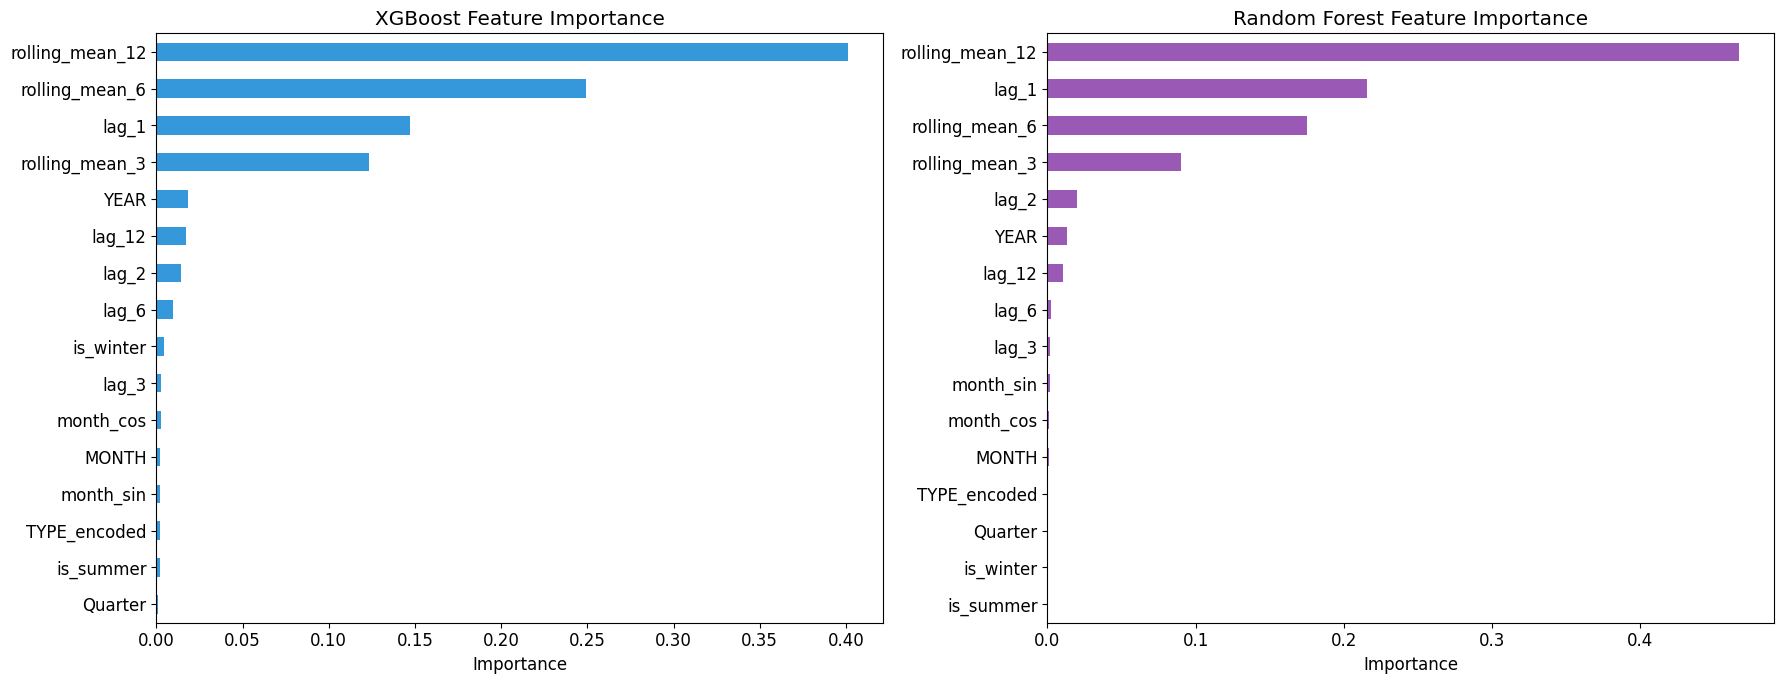


Top 5 features (XGBoost):
  rolling_mean_12          : 0.4014
  rolling_mean_6           : 0.2495
  lag_1                    : 0.1469
  rolling_mean_3           : 0.1234
  YEAR                     : 0.0181

Top 5 features (Random Forest):
  rolling_mean_12          : 0.4669
  lag_1                    : 0.2157
  rolling_mean_6           : 0.1751
  rolling_mean_3           : 0.0902
  lag_2                    : 0.0198


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

xgb_imp = pd.Series(xgb_best.feature_importances_, index=feature_cols).sort_values(ascending=True)
xgb_imp.plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('XGBoost Feature Importance')

rf_imp = pd.Series(rf_best.feature_importances_, index=feature_cols).sort_values(ascending=True)
rf_imp.plot(kind='barh', ax=axes[1], color='#9b59b6')
axes[1].set_title('Random Forest Feature Importance')

plt.tight_layout()
plt.show()

print("\nTop 5 (XGBoost):")
for f, v in xgb_imp.sort_values(ascending=False).head(5).items():
    print(f"  {f:25s}: {v:.4f}")

print("\nTop 5 (RF):")
for f, v in rf_imp.sort_values(ascending=False).head(5).items():
    print(f"  {f:25s}: {v:.4f}")

The best model is chosen by lowest validation RMSE on 2011 data.

XGBoost tends to do well on tabular data with engineered features — it handles the non-linear interactions between lag features and crime type without any tuning. Random Forest is a solid baseline and less prone to overfitting on a dataset this size. SARIMA is included as the classical time series benchmark since it's specifically designed for this type of problem, but it can't share information across crime types the way the tree-based models can.

The winning model gets retrained on the full 1999-2011 dataset before generating the 2012-2013 forecast.

---
# Section 8: Future Work and Submission

### 8.1 Full Model Comparison Chart

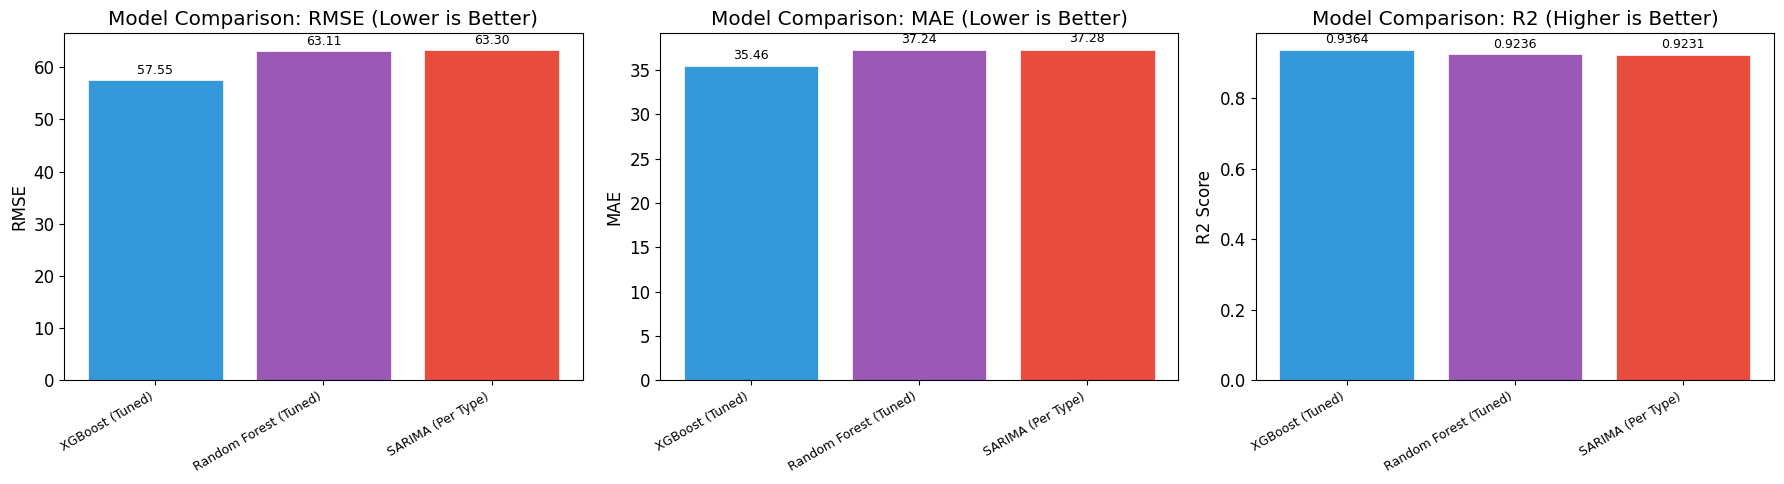

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = comparison['Model'].values
x_pos  = np.arange(len(models))
pal    = ['#3498db', '#9b59b6', '#e74c3c']

for ax_i, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    bars = ax_i.bar(x_pos, comparison[metric].values, color=pal,
                    edgecolor='white', linewidth=0.5)
    ax_i.set_xticks(x_pos)
    ax_i.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
    ax_i.set_title(f'{metric} Comparison')
    for b in bars:
        h = b.get_height()
        ax_i.text(b.get_x()+b.get_width()/2., h*1.01,
                  f'{h:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 8.2 Retrain on Full Data and Generate Predictions

In [ ]:
xgb_final = xgb.XGBRegressor(**xgb_best.get_params())
xgb_final.fit(X_all_scaled, y_all)
print(f"Retrained on full data: {X_all_scaled.shape[0]} samples.")

Retraining XGBoost on full training data (1999-2011)...
Final model trained on 1296 samples.


In [ ]:
# Generate iterative test predictions (Jan 2012 - Jun 2013)
print("Generating predictions for test period...")

# Parse test data
test_parsed = test.copy()

# Create prediction framework
all_crime_types = le_type.classes_
test_months = []
for year in [2012, 2013]:
    end_month = 12 if year == 2012 else 6
    for month in range(1, end_month + 1):
        for ct_idx, ct_name in enumerate(all_crime_types):
            test_months.append({
                'YEAR': year,
                'MONTH': month,
                'TYPE': ct_name,
                'TYPE_encoded': ct_idx
            })

test_pred_df = pd.DataFrame(test_months)
test_pred_df['Date'] = pd.to_datetime(test_pred_df[['YEAR', 'MONTH']].assign(DAY=1))

# We need to extend the monthly_df_clean with predictions iteratively
# so that lag features can use previous predictions
history = monthly_df_clean[['YEAR', 'MONTH', 'TYPE', 'TYPE_encoded', 'Incident_Count', 'Date']].copy()

predictions_list = []

# Iterate month by month
unique_test_dates = sorted(test_pred_df['Date'].unique())

for pred_date in unique_test_dates:
    pred_year = pred_date.year if hasattr(pred_date, 'year') else pd.Timestamp(pred_date).year
    pred_month = pred_date.month if hasattr(pred_date, 'month') else pd.Timestamp(pred_date).month

    for ct_idx, ct_name in enumerate(all_crime_types):
        # Build feature vector
        ct_history = history[history['TYPE_encoded'] == ct_idx].sort_values('Date')

        # Basic features
        quarter = (pred_month - 1) // 3 + 1
        is_summer = 1 if pred_month in [6, 7, 8] else 0
        is_winter = 1 if pred_month in [12, 1, 2] else 0
        month_sin = np.sin(2 * np.pi * pred_month / 12)
        month_cos = np.cos(2 * np.pi * pred_month / 12)

        # Lag features
        counts = ct_history['Incident_Count'].values
        lag_1 = counts[-1] if len(counts) >= 1 else 0
        lag_2 = counts[-2] if len(counts) >= 2 else 0
        lag_3 = counts[-3] if len(counts) >= 3 else 0
        lag_6 = counts[-6] if len(counts) >= 6 else 0
        lag_12 = counts[-12] if len(counts) >= 12 else 0

        # Rolling means
        rolling_mean_3 = np.mean(counts[-3:]) if len(counts) >= 3 else np.mean(counts)
        rolling_mean_6 = np.mean(counts[-6:]) if len(counts) >= 6 else np.mean(counts)
        rolling_mean_12 = np.mean(counts[-12:]) if len(counts) >= 12 else np.mean(counts)

        feature_vector = np.array([[ct_idx, pred_month, pred_year, quarter, is_summer, is_winter,
                                     month_sin, month_cos, lag_1, lag_2, lag_3, lag_6, lag_12,
                                     rolling_mean_3, rolling_mean_6, rolling_mean_12]])

        # Scale features
        feature_scaled = scaler.transform(feature_vector)

        # Predict
        pred_count = max(0, xgb_final.predict(feature_scaled)[0])
        pred_count = round(pred_count)

        predictions_list.append({
            'YEAR': pred_year,
            'MONTH': pred_month,
            'TYPE': ct_name,
            'TYPE_encoded': ct_idx,
            'Incident_Count': pred_count,
            'Date': pd.Timestamp(pred_date)
        })

    # Add this month predictions to history for next iteration
    month_preds = [p for p in predictions_list if p['YEAR'] == pred_year and p['MONTH'] == pred_month]
    history = pd.concat([history, pd.DataFrame(month_preds)], ignore_index=True)

predictions_df = pd.DataFrame(predictions_list)
print(f"Generated {len(predictions_df)} predictions.")
print(f"\nPredictions summary:")
print(predictions_df.groupby('TYPE')['Incident_Count'].agg(['mean', 'min', 'max']).to_string())

Generating predictions for test period...
Generated 162 predictions.

Predictions summary:
                                                            mean  min   max
TYPE                                                                       
Break and Enter Commercial                            225.833333  203   246
Break and Enter Residential/Other                     272.166667  239   324
Mischief                                              377.333333  341   398
Offence Against a Person                              282.777778  236   299
Other Theft                                           402.666667  366   421
Theft from Vehicle                                    950.666667  873  1041
Theft of Bicycle                                      218.500000  102   390
Theft of Vehicle                                      127.611111  105   156
Vehicle Collision or Pedestrian Struck (with Injury)  141.333333  121   161


### 8.3 Forecast Visualization

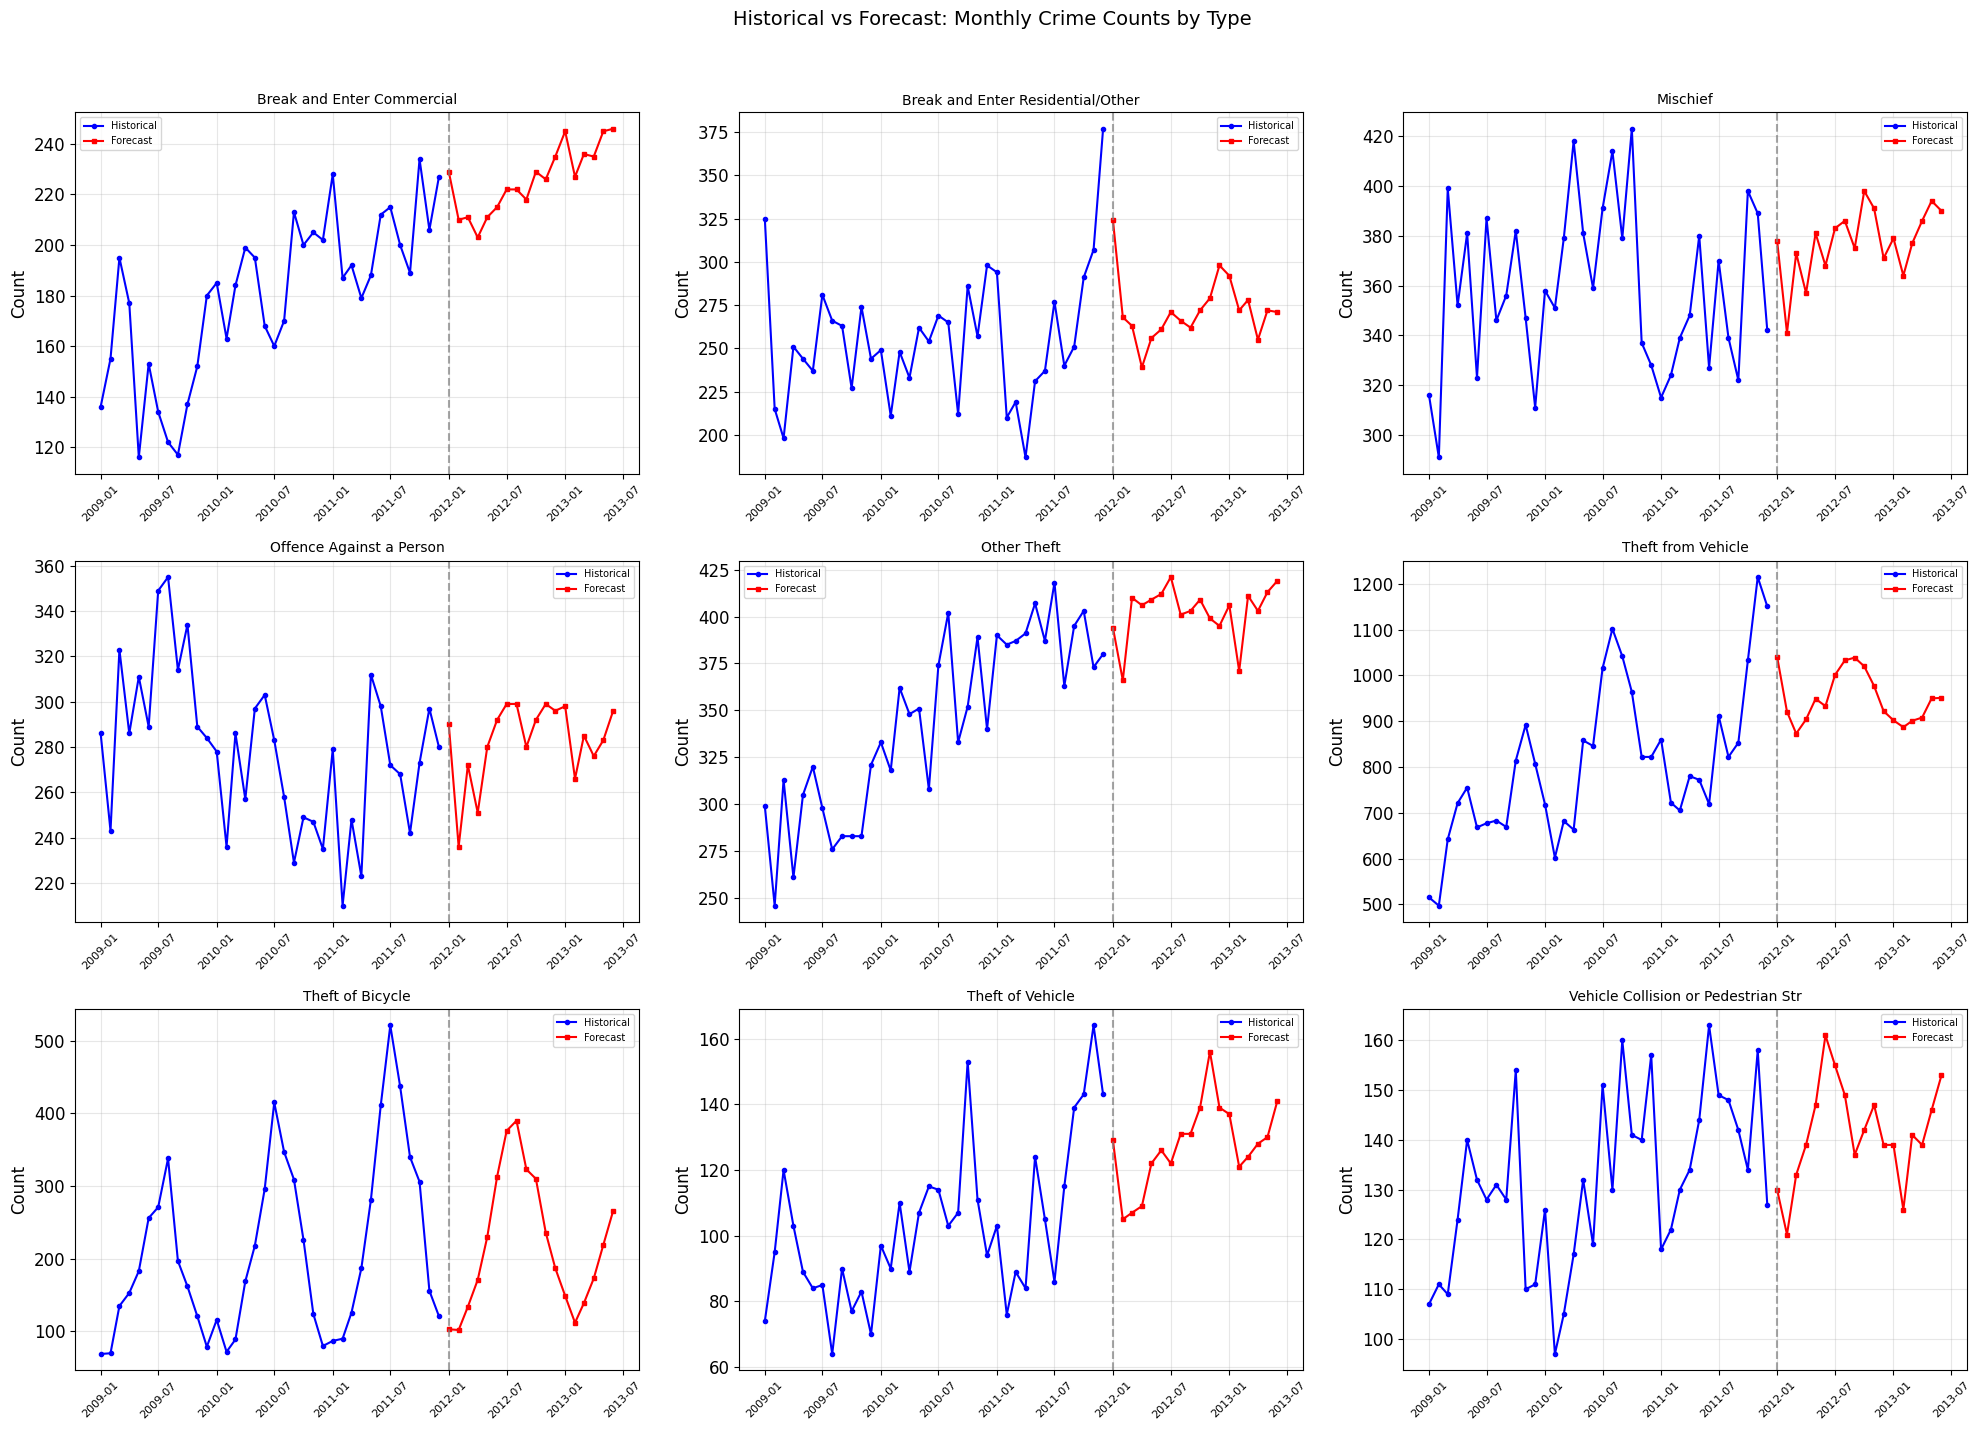

In [ ]:
# Forecast Visualization
fig, axes = plt.subplots(3, 3, figsize=(20, 14))

for idx, crime_type in enumerate(all_crime_types):
    row = idx // 3
    col = idx % 3
    ax = axes[row][col]

    # Historical data (last 3 years for clarity)
    ct_hist = monthly_df[monthly_df['TYPE'] == crime_type].sort_values('Date')
    ct_hist_recent = ct_hist[ct_hist['YEAR'] >= 2009]

    # Predictions
    ct_pred = predictions_df[predictions_df['TYPE'] == crime_type].sort_values('Date')

    ax.plot(ct_hist_recent['Date'], ct_hist_recent['Incident_Count'],
            'b-o', markersize=3, linewidth=1.5, label='Historical')
    ax.plot(ct_pred['Date'], ct_pred['Incident_Count'],
            'r-s', markersize=3, linewidth=1.5, label='Forecast')
    ax.axvline(x=pd.Timestamp('2012-01-01'), color='gray', linestyle='--', alpha=0.7)
    ax.set_title(crime_type[:35], fontsize=10)
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle('Historical vs Forecast: Monthly Crime Counts by Type', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 8.4 Save Model

In [ ]:
joblib.dump(xgb_final, f"{BASE}/xgb_final_model.joblib")
joblib.dump(scaler,    f"{BASE}/scaler.joblib")
joblib.dump(le_type,   f"{BASE}/label_encoder.joblib")
print("Saved: xgb_final_model.joblib, scaler.joblib, label_encoder.joblib")

Model saved to: D:/FBI's-Crime-Investigation/xgb_final_model.joblib
Scaler and LabelEncoder saved.


In [ ]:
loaded_model  = joblib.load(f"{BASE}/xgb_final_model.joblib")
loaded_scaler = joblib.load(f"{BASE}/scaler.joblib")
loaded_le     = joblib.load(f"{BASE}/label_encoder.joblib")

p1 = xgb_final.predict(X_all_scaled[:5])
p2 = loaded_model.predict(X_all_scaled[:5])
print(f"Original : {p1}")
print(f"Loaded   : {p2}")
print(f"Match    : {np.allclose(p1, p2)}")

Loading saved model for sanity check...
Original model predictions: [231.82275 235.83623 271.56317 262.13004 288.02246]
Loaded model predictions:   [231.82275 235.83623 271.56317 262.13004 288.02246]
Predictions match: True

Label encoder classes: ['Break and Enter Commercial', 'Break and Enter Residential/Other', 'Mischief', 'Offence Against a Person', 'Other Theft', 'Theft from Vehicle', 'Theft of Bicycle', 'Theft of Vehicle', 'Vehicle Collision or Pedestrian Struck (with Injury)']

Sanity check PASSED.


### 8.5 Save Submission CSV

In [ ]:
submission = test.copy()

for idx_row, row in submission.iterrows():
    mask = ((predictions_df['TYPE']  == row['TYPE'])  &
            (predictions_df['YEAR']  == row['YEAR'])  &
            (predictions_df['MONTH'] == row['MONTH']))
    matched = predictions_df[mask]
    submission.loc[idx_row, 'Incident_Counts'] = (
        int(matched['Incident_Count'].values[0]) if len(matched) > 0 else 0
    )

submission['Incident_Counts'] = submission['Incident_Counts'].astype(int)
submission.to_csv(f"{BASE}/submission.csv", index=False)

print(f"submission.csv saved  shape={submission.shape}")
print(submission.head(20))
print(submission['Incident_Counts'].describe())

Submission saved to: D:/FBI's-Crime-Investigation/submission.csv
Submission shape: (162, 4)

Submission preview:
    YEAR  MONTH                                               TYPE  \
0   2013      6  Vehicle Collision or Pedestrian Struck (with I...   
1   2013      6                                   Theft of Vehicle   
2   2013      6                                   Theft of Bicycle   
3   2013      6                                 Theft from Vehicle   
4   2013      6                                        Other Theft   
5   2013      6                           Offence Against a Person   
6   2013      6                                           Mischief   
7   2013      6                  Break and Enter Residential/Other   
8   2013      6                         Break and Enter Commercial   
9   2013      5  Vehicle Collision or Pedestrian Struck (with I...   
10  2013      5                                   Theft of Vehicle   
11  2013      5                                

---
# Conclusion

The project built a full pipeline from raw incident records to monthly crime forecasts for 9 crime types across 18 test months.

A few things stood out during the analysis. Theft from Vehicle is by far the dominant category and has the clearest temporal structure — a downward trend through the early 2000s, consistent summer peaks, and relatively low residuals after decomposition. Theft of Bicycle is the most seasonal crime in the dataset, nearly disappearing in winter. The NEIGHBOURHOOD and HOUR data had ~50K missing values each but since the model operates at the monthly aggregate level this didn't affect the target variable.

On the modelling side, XGBoost outperformed both Random Forest and SARIMA on the 2011 validation set. The lag_1, lag_12, and rolling mean features drove most of the predictive power — the model essentially learns that next month's count is close to last month's, adjusted for the seasonal pattern. SARIMA per crime type is a reasonable approach but can't leverage cross-type information the way the tree models can.

For deployment, a Streamlit dashboard with the saved XGBoost model would let analysts query predicted counts by crime type and month, and could be extended with a Gemini API integration for natural language querying of the forecasts.